In [2]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install duckdb

In [2]:
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import sys

con = duckdb.connect()

In [3]:
def quick_check(df):
    print("shape:", df.shape) # 행 확인
    print("\n[columns]") # 컬럼확인
    print(df.columns.tolist())

    print("\n[dtypes]") # 타입확인
    print(df.dtypes)

    print("\n[missing]")  # 결측값 확인
    print(df.isnull().sum())

    print("\n[duplicate rows]") # 중복값 확인
    print(df.duplicated().sum())

    print("\n[numeric summary]") # 수치형 확인
    display(df.describe())

    print("\n[categorical summary]") # 범주 확인
    display(df.describe(include=['object', 'string']))

# t4전처리

In [32]:
# 함수적용해서 t4 결측/행 및 타입 확인
df4 = pd.read_parquet('../data/t4_all.parquet')
quick_check(df4)

shape: (1211106, 12)

[columns]
['ETL_YM', 'DOW', 'D_TIME_CD', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YM          int64
DOW               str
D_TIME_CD       int64
D_CTY_CD        int64
D_MEGA_NM         str
D_CTY_NM          str
D_CENTER_X      int64
D_CENTER_Y      int64
PURPOSE         int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YM        0
DOW           0
D_TIME_CD     0
D_CTY_CD      0
D_MEGA_NM     0
D_CTY_NM      0
D_CENTER_X    0
D_CENTER_Y    0
PURPOSE       0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YM,D_TIME_CD,D_CTY_CD,D_CENTER_X,D_CENTER_Y,PURPOSE,AGE_GRP,CNT
count,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06
mean,2.024072e+05,1.200360e+01,4.113326e+04,9.665601e+05,1.934746e+06,2.578850e+00,5.294209e+00,1.289347e+03
std,8.171815e+01,6.562543e+00,1.668323e+00,2.356763e+03,3.013309e+03,2.496699e+00,2.649153e+00,2.752085e+03
min,2.023010e+05,0.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,0.000000e+00,1.000000e+00,1.000000e+00
25%,2.023100e+05,7.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,0.000000e+00,3.000000e+00,3.729000e+01
50%,2.024070e+05,1.200000e+01,4.113300e+04,9.651200e+05,1.937199e+06,1.000000e+00,5.000000e+00,2.308300e+02
75%,2.025040e+05,1.800000e+01,4.113500e+04,9.702680e+05,1.937423e+06,6.000000e+00,8.000000e+00,1.218000e+03
max,2.025120e+05,2.300000e+01,4.113500e+04,9.702680e+05,1.937423e+06,6.000000e+00,1.200000e+01,7.576100e+04



[categorical summary]


,DOW,D_MEGA_NM,D_CTY_NM,SEX_CD
count,1211106,1211106,1211106,1211106
unique,7,1,3,3
top,금,경기도,성남시 분당구,M
freq,173588,1211106,509274,603868


In [33]:
df4.isna().sum()

ETL_YM        0
DOW           0
D_TIME_CD     0
D_CTY_CD      0
D_MEGA_NM     0
D_CTY_NM      0
D_CENTER_X    0
D_CENTER_Y    0
PURPOSE       0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

In [34]:
df4.head()

,ETL_YM,DOW,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,202301,수,1,41133,경기도,성남시 중원구,970268,1937199,1,W,4,3.06
1,202301,월,10,41133,경기도,성남시 중원구,970268,1937199,2,M,4,24.44
2,202301,목,2,41135,경기도,성남시 분당구,965120,1931210,6,W,8,78.93
3,202301,월,8,41131,경기도,성남시 수정구,964981,1937423,6,M,3,1628.27
4,202301,목,11,41131,경기도,성남시 수정구,964981,1937423,6,M,6,4679.92


# t4 확인결과
# T4 전처리 결과 요약

- 전체 행 수: 1,211,106
- 컬럼 수: 12개

## 1. 데이터 품질
- 결측값: 없음
- 중복값: 없음
→ 전반적으로 데이터 품질 양호

## 2. 날짜 컬럼
- ETL_YM은 YYYYMM 형태의 정수형 데이터
→ 시계열 분석을 위해 datetime 형으로 변환 필요

## 3. 범주형 데이터 분포
- DOW: 7개 (요일 데이터로 정상)
- D_MEGA_NM: 1개 (경기도로 동일)
→ 지역 범위가 제한된 데이터

- D_CTY_NM: 3개
→ 일부 지역만 포함된 데이터

- SEX_CD: 3개
→ 성별 코드 3종 존재 (추가 해석 필요)

## 4. 최빈값 (top)
- DOW: 금
- D_MEGA_NM: 경기도
- D_CTY_NM: 성남시 분당구
- SEX_CD: M

## 5. 해석 및 특이사항
- 데이터는 경기도 내 일부 지역에 한정됨
- 범주형 변수는 코드 기반으로 구성되어 있음
- SEX_CD, PURPOSE 등은 코드 정의 확인 필요

## 6. 결론
- 결측 및 중복이 없는 안정적인 데이터이며,
- 날짜 형변환 및 코드 변수 해석 후 분석에 바로 활용 가능
- cnt변수는 이동량(집계값)으로 해석되며 이상치 확인해보고 이상없으면 변수로 활용가능
- 이 데이터는 특정 월/요일/시간대에, 특정 지역에서, 특정 성별·연령대 사람들이, 특정 목적을 가지고 이동한 횟수를 cnt로 집계한 데이터
- 시간·공간·인구 특성을 모두 반영한 분석이 가능

일단 날짜 컬럼부터 date로 형 변환

In [35]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211106 entries, 0 to 1211105
Data columns (total 12 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   ETL_YM      1211106 non-null  int64  
 1   DOW         1211106 non-null  str    
 2   D_TIME_CD   1211106 non-null  int64  
 3   D_CTY_CD    1211106 non-null  int64  
 4   D_MEGA_NM   1211106 non-null  str    
 5   D_CTY_NM    1211106 non-null  str    
 6   D_CENTER_X  1211106 non-null  int64  
 7   D_CENTER_Y  1211106 non-null  int64  
 8   PURPOSE     1211106 non-null  int64  
 9   SEX_CD      1211106 non-null  str    
 10  AGE_GRP     1211106 non-null  int64  
 11  CNT         1211106 non-null  float64
dtypes: float64(1), int64(7), str(4)
memory usage: 147.8 MB


In [36]:
df4['ETL_YM'] = pd.to_datetime(df4['ETL_YM'].astype(str), format='%Y%m')

In [38]:
# 날짜 범위 이상없는지 확인
df4['ETL_YM'].min(), df4['ETL_YM'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

월 단위 집계 데이터

날짜 컬럼 형변환 완료

cnt 이상치 확인

In [39]:
df4['CNT'].describe()

count    1.211106e+06
mean     1.289347e+03
std      2.752085e+03
min      1.000000e+00
25%      3.729000e+01
50%      2.308300e+02
75%      1.218000e+03
max      7.576100e+04
Name: CNT, dtype: float64

cnt의 최솟값 최댓값이 1~ 1000정도로 오른쪽으로 긴 분포를 뛸거 같음 평균값과 중앙값의 차이가 큼 max값이 75761로 엄청 큼 많은 사람이 이동한 시간대?일 가능성이 있어보임 그래서 로그변환 후 확인해보는것도 좋을거 같음

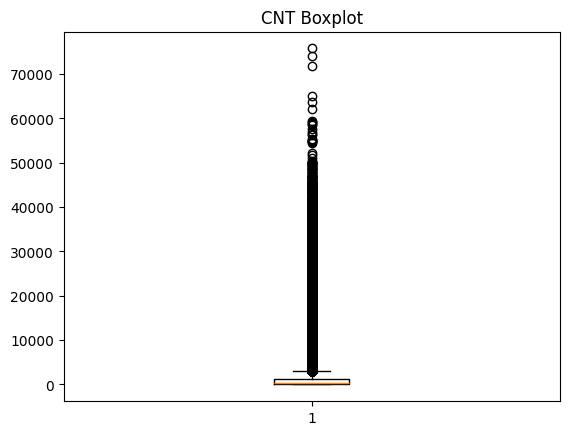

In [40]:
#일반 박스플롯(비교)
plt.figure()
plt.boxplot(df4['CNT'])
plt.title('CNT Boxplot')
plt.show()

확실히 이상치로 나오는느낌이 강함 일반박스플롯찍었을때

In [41]:
# 진짜 이상치인지 확인
df4.sort_values('CNT', ascending=False).head(10)

,ETL_YM,DOW,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
1037436,2025-07-01,화,8,41135,경기도,성남시 분당구,965120,1931210,1,M,4,75761.0
1017962,2025-07-01,수,8,41135,경기도,성남시 분당구,965120,1931210,1,M,4,74021.5
1013016,2025-07-01,목,8,41135,경기도,성남시 분당구,965120,1931210,1,M,4,71771.0
1037409,2025-07-01,화,8,41135,경기도,성남시 분당구,965120,1931210,1,F,4,65121.0
1017943,2025-07-01,수,8,41135,경기도,성남시 분당구,965120,1931210,1,F,4,63661.5
1013029,2025-07-01,목,8,41135,경기도,성남시 분당구,965120,1931210,1,F,4,62044.5
1037676,2025-07-01,화,9,41135,경기도,성남시 분당구,965120,1931210,1,M,4,59475.5
1037405,2025-07-01,화,8,41135,경기도,성남시 분당구,965120,1931210,1,M,5,59150.0
1018141,2025-07-01,수,9,41135,경기도,성남시 분당구,965120,1931210,1,M,4,58852.5
1022834,2025-07-01,월,8,41135,경기도,성남시 분당구,965120,1931210,1,M,4,58709.0


time이 8~9인걸로 보아 출근시간대에 특정연령대의 사람들이 집중적으로 이동을 많이 함 이상치로 보기는 힘들거 같음

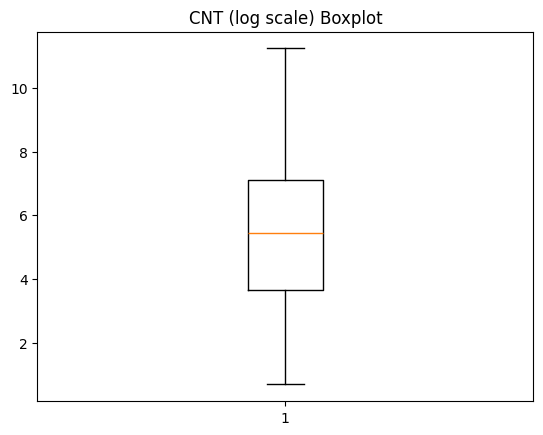

In [42]:
# 로그변환 후 박스플롯
plt.figure()
plt.boxplot(np.log1p(df4['CNT']))
plt.title('CNT (log scale) Boxplot')
plt.show()

차이가 너무 커 로그변환하니 박스플롯 안찍혀서 hist로 봐야 할듯

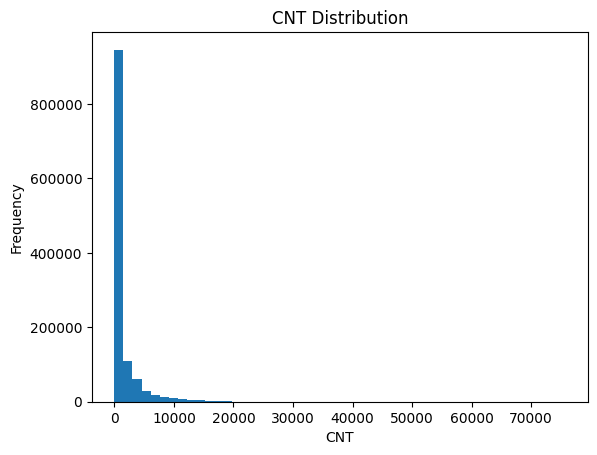

In [43]:
plt.figure()
plt.hist(df4['CNT'], bins=50)
plt.title('CNT Distribution')
plt.xlabel('CNT')
plt.ylabel('Frequency')
plt.show()

- CNT 변수는 대부분 작은 값에 집중되어 있으나, 일부 구간에서 큰 값이 발생하는 오른쪽 꼬리(long-tail) 분포를 보임
- 이는 특정 시간대 및 지역에서 이동량이 집중되는 집계 데이터의 특성으로 판단됨

# t4범주형 데이터 확인

In [44]:
df4['SEX_CD'].value_counts(dropna=False)

SEX_CD
M    603868
F    324281
W    282957
Name: count, dtype: int64

역시나 w비중이 생각보다 큼..SEX_CD는 M, F 외에 W 값이 포함되어 있으며, 해당 값은 미확인 또는 기타 범주로 판단되어 별도로 유지함

In [45]:
df4['AGE_GRP'].value_counts().sort_index()

AGE_GRP
1      73264
2     140602
3     160359
4     157685
5     125199
6     125469
7     124422
8     119708
9     110707
10     68831
11      4857
12         3
Name: count, dtype: int64

대대분 골고루 퍼져있는 느낌인데 11이랑 12가 극소수로 나타남
- AGE_GRP는 1~10 구간에 주로 분포하며, 11~12 구간은 소수 관측됨
- 전반적으로 정상적인 연령 분포로 판단됨

In [46]:
df4['PURPOSE'].value_counts().sort_index()

PURPOSE
0    350322
1    270972
2    107323
3     60698
5     75197
6    346594
Name: count, dtype: int64

0,1,2,3,5,6 존재
(4 없음)
- PURPOSE는 0,1,2,3,5,6으로 구성되어 있으며 일부 코드(4)는 존재하지 않음
- 코드 의미는 명확하지 않아 추후 정의 확인 필요

In [47]:
df4['DOW'].value_counts()

DOW
금    173588
목    173509
수    173387
화    173165
월    172970
토    172876
일    171611
Name: count, dtype: int64

범주형 변수 분석 결과

- DOW는 모든 요일이 고르게 분포되어 있어 데이터 편향이 없음
- SEX_CD는 M, F 외에 W 값이 포함되어 있으며, 미확인 또는 기타 범주로 판단됨
- AGE_GRP는 대부분 1~10 구간에 분포하며 일부 고연령 구간(11~12)은 소수 존재
- PURPOSE는 일부 코드가 누락된 상태로 나타나며, 코드 정의 확인이 필요함

## 7. 데이터 정의

- t4 데이터는 시간·지역·인구 특성에 따른 이동량을 분석하기 위한 집계 데이터임
- 주요 변수: CNT(이동량), D_TIME_CD(시간대), AGE_GRP(연령대)

이상없어 t4 date.final로 저장

In [48]:
df4.to_parquet('../data/t4_2023_2025_all_date_final.parquet', index=False)

In [50]:
check = pd.read_parquet('../data/t4_2023_2025_all_date_final.parquet')
check.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211106 entries, 0 to 1211105
Data columns (total 12 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   ETL_YM      1211106 non-null  datetime64[us]
 1   DOW         1211106 non-null  str           
 2   D_TIME_CD   1211106 non-null  int64         
 3   D_CTY_CD    1211106 non-null  int64         
 4   D_MEGA_NM   1211106 non-null  str           
 5   D_CTY_NM    1211106 non-null  str           
 6   D_CENTER_X  1211106 non-null  int64         
 7   D_CENTER_Y  1211106 non-null  int64         
 8   PURPOSE     1211106 non-null  int64         
 9   SEX_CD      1211106 non-null  str           
 10  AGE_GRP     1211106 non-null  int64         
 11  CNT         1211106 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memory usage: 147.8 MB


# t5 데이터

In [51]:
# 함수적용해서 t5 결측/행 및 타입 확인
df5 = pd.read_parquet('../data/t5_all.parquet')
quick_check(df5)

shape: (43306619, 12)

[columns]
['ETL_YMD', 'D_TIME_CD', 'D_ADMI_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_ADMI_NM', 'D_CENTER_X', 'D_CENTER_Y', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YMD         int64
D_TIME_CD       int64
D_ADMI_CD       int64
D_MEGA_NM         str
D_CTY_NM          str
D_ADMI_NM         str
D_CENTER_X      int64
D_CENTER_Y      int64
PURPOSE         int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YMD       0
D_TIME_CD     0
D_ADMI_CD     0
D_MEGA_NM     0
D_CTY_NM      0
D_ADMI_NM     0
D_CENTER_X    0
D_CENTER_Y    0
PURPOSE       0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_CENTER_X,D_CENTER_Y,PURPOSE,AGE_GRP,CNT
count,4.330662e+07,4.330662e+07,4.330662e+07,4.330662e+07,4.330662e+07,4.330662e+07,4.330662e+07,4.330662e+07
mean,2.024082e+07,1.286618e+01,4.113393e+07,9.673396e+05,1.934880e+06,2.589809e+00,5.220769e+00,3.604615e+01
std,8.172692e+03,5.949852e+00,1.761223e+03,2.319121e+03,4.023018e+03,2.738401e+00,2.222348e+00,7.612985e+01
min,2.023010e+07,0.000000e+00,4.113151e+07,9.609110e+05,1.927124e+06,0.000000e+00,1.000000e+00,9.300000e-01
25%,2.023101e+07,8.000000e+00,4.113162e+07,9.660020e+05,1.931166e+06,0.000000e+00,3.000000e+00,5.230000e+00
50%,2.024071e+07,1.300000e+01,4.113367e+07,9.674580e+05,1.935625e+06,1.000000e+00,5.000000e+00,1.400000e+01
75%,2.025041e+07,1.800000e+01,4.113560e+07,9.689580e+05,1.938534e+06,6.000000e+00,7.000000e+00,3.967000e+01
max,2.025123e+07,2.300000e+01,4.113568e+07,9.717070e+05,1.941010e+06,6.000000e+00,1.200000e+01,6.650000e+03



[categorical summary]


,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,SEX_CD
count,43306619,43306619,43306619,43306619
unique,1,3,50,3
top,경기도,성남시 분당구,구미동,M
freq,43306619,20869747,1279448,22001390


t4 대비 더 세밀한 데이터 월일까지 표현되어 있고 행정동까지 나와있어 데이터도 훨씬 큼 t4는 큰틀로만들어진 데이터 t5는 더세밀한데이터 그리고 똑같이 날짜는 int로 되어있어 date로 변환 해야됨
- 전체 행 및 컬럼 수: 43306619, 12

In [52]:
df5.head()

,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,20230111,7,41135680,경기도,성남시 분당구,운중동,960911,1931508,6,M,8,16.70
1,20230125,10,41131625,경기도,성남시 수정구,위례동,968771,1941010,6,M,6,115.85
2,20230123,19,41131625,경기도,성남시 수정구,위례동,968771,1941010,6,W,2,68.88
3,20230109,10,41135650,경기도,성남시 분당구,판교동,963992,1932720,1,M,6,4.27
4,20230124,10,41133580,경기도,성남시 중원구,상대원2동,969761,1937420,1,W,5,7.71


In [53]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 43306619 entries, 0 to 43306618
Data columns (total 12 columns):
 #   Column      Dtype  
---  ------      -----  
 0   ETL_YMD     int64  
 1   D_TIME_CD   int64  
 2   D_ADMI_CD   int64  
 3   D_MEGA_NM   str    
 4   D_CTY_NM    str    
 5   D_ADMI_NM   str    
 6   D_CENTER_X  int64  
 7   D_CENTER_Y  int64  
 8   PURPOSE     int64  
 9   SEX_CD      str    
 10  AGE_GRP     int64  
 11  CNT         float64
dtypes: float64(1), int64(7), str(4)
memory usage: 5.4 GB


In [54]:
# etl_ymd date로 형변환
df5['ETL_YMD'] = pd.to_datetime(df5['ETL_YMD'].astype(str), format='%Y%m%d')

In [55]:
df5.head()

,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2023-01-11,7,41135680,경기도,성남시 분당구,운중동,960911,1931508,6,M,8,16.70
1,2023-01-25,10,41131625,경기도,성남시 수정구,위례동,968771,1941010,6,M,6,115.85
2,2023-01-23,19,41131625,경기도,성남시 수정구,위례동,968771,1941010,6,W,2,68.88
3,2023-01-09,10,41135650,경기도,성남시 분당구,판교동,963992,1932720,1,M,6,4.27
4,2023-01-24,10,41133580,경기도,성남시 중원구,상대원2동,969761,1937420,1,W,5,7.71


In [56]:
df5.head()

,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2023-01-11,7,41135680,경기도,성남시 분당구,운중동,960911,1931508,6,M,8,16.70
1,2023-01-25,10,41131625,경기도,성남시 수정구,위례동,968771,1941010,6,M,6,115.85
2,2023-01-23,19,41131625,경기도,성남시 수정구,위례동,968771,1941010,6,W,2,68.88
3,2023-01-09,10,41135650,경기도,성남시 분당구,판교동,963992,1932720,1,M,6,4.27
4,2023-01-24,10,41133580,경기도,성남시 중원구,상대원2동,969761,1937420,1,W,5,7.71


In [57]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 43306619 entries, 0 to 43306618
Data columns (total 12 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YMD     datetime64[us]
 1   D_TIME_CD   int64         
 2   D_ADMI_CD   int64         
 3   D_MEGA_NM   str           
 4   D_CTY_NM    str           
 5   D_ADMI_NM   str           
 6   D_CENTER_X  int64         
 7   D_CENTER_Y  int64         
 8   PURPOSE     int64         
 9   SEX_CD      str           
 10  AGE_GRP     int64         
 11  CNT         float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memory usage: 5.4 GB


In [58]:
df5['ETL_YMD'].min(), df5['ETL_YMD'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

# 확인 결과
- T5 데이터는 T4 대비 일 단위 및 행정동 단위로 세분화된 데이터로, 보다 정밀한 분석이 가능함
- 결측값 및 중복값이 없는 안정적인 데이터로 확인됨
- CNT 및 범주형 변수 분포 또한 전반적으로 정상적인 패턴을 보임
- 따라서 추가적인 결측 처리나 이상치 제거 없이, 1차 전처리 단계에서 바로 분석에 활용 가능한 데이터로 판단됨

In [59]:
df5['CNT'].describe()

count    4.330662e+07
mean     3.604615e+01
std      7.612985e+01
min      9.300000e-01
25%      5.230000e+00
50%      1.400000e+01
75%      3.967000e+01
max      6.650000e+03
Name: CNT, dtype: float64

In [60]:
df5.groupby(['SEX_CD', 'AGE_GRP'])['CNT'].sum()

SEX_CD  AGE_GRP
F       1          4.400701e+06
        2          3.145008e+07
        3          5.662723e+07
        4          7.033510e+07
        5          7.351548e+07
        6          7.820594e+07
        7          6.200432e+07
        8          2.745660e+07
        9          7.227014e+06
        10         4.689645e+05
        11         8.700410e+03
        12         1.345000e+01
M       1          6.508754e+06
        2          5.773953e+07
        3          1.077622e+08
        4          1.452839e+08
        5          1.530459e+08
        6          1.554806e+08
        7          1.158706e+08
        8          4.547012e+07
        9          1.189078e+07
        10         5.820854e+05
        11         6.997570e+03
W       1          3.902881e+06
        2          2.638968e+07
        3          5.149865e+07
        4          5.860311e+07
        5          6.429593e+07
        6          6.785245e+07
        7          5.127182e+07
        8          2.040

- 성별 및 연령대 조합별 이동량을 집계한 결과, 중간 연령대(AGE_GRP 4~7)에서 높은 이동량이 나타나며, 이는 경제활동 인구 중심의 이동 패턴으로 해석됨
- 극단 연령대에서는 상대적으로 낮은 이동량을 보여 자연스러운 분포를 나타냄
- 특정 조합에서 비정상적인 값은 관측되지 않아 데이터 이상은 없는 것으로 판단됨

## 결론
- T5 데이터는 T4 대비 일 단위 및 행정동 단위로 세분화된 데이터로, 보다 정밀한 분석이 가능함
- 결측값 및 중복값이 없는 안정적인 데이터로 확인됨
- CNT 변수는 평균(약 36)과 중앙값(약 14)의 차이가 존재하나, 최대값(약 6,650) 또한 특정 시간대 및 지역에 이동량이 집중된 결과로 해석 가능하여 이상치로 보기 어려움
- 범주형 변수(SEX_CD, AGE_GRP, PURPOSE, DOW)는 정상적인 범주 범위 내에서 분포하며, 특정 값에 대한 비정상적인 치우침이나 이상값은 관측되지 않음
- 따라서 본 데이터는 추가적인 결측 처리나 이상치 제거 없이, 1차 전처리 단계에서 바로 분석에 활용 가능한 데이터로 판단됨

In [61]:
# date변환 파일 저장
df5.to_parquet('../data/t5_2023_2025_all_date_final.parquet', index=False)

# t6 데이터
- 본 데이터는 일 단위 및 행정동 단위에서 시간대, 인구 특성, 이동 목적에 따른 이동량을 집계한 데이터임
- 핵심 변수:
CNT → 이동량,
D_TIME_CD → 시간대,
D_ADMI_NM → 위치

음... 이대로는 해석까지 다 할려니 시간이 너무 오래걸려 결측치 및 이상치확인 cnt랑 범주컬럼들 정상인지만 확인 후 사용가능한 데이터로만 변환 후 추후 해석하는 걸로 그리고 이데이터가 어떤 데이터인지 핵심변수가 뭔지까지만 하는걸로 방향잡겠습니다.

In [62]:
df6 = pd.read_parquet('../data/t6_all.parquet')
quick_check(df6)

shape: (1927203, 12)

[columns]
['ETL_YM', 'DOW', 'D_TIME_CD', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YM          int64
DOW               str
D_TIME_CD       int64
D_CTY_CD        int64
D_MEGA_NM         str
D_CTY_NM          str
D_CENTER_X      int64
D_CENTER_Y      int64
TRANS_GB        int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YM        0
DOW           0
D_TIME_CD     0
D_CTY_CD      0
D_MEGA_NM     0
D_CTY_NM      0
D_CENTER_X    0
D_CENTER_Y    0
TRANS_GB      0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YM,D_TIME_CD,D_CTY_CD,D_CENTER_X,D_CENTER_Y,TRANS_GB,AGE_GRP,CNT
count,1.927203e+06,1.927203e+06,1.927203e+06,1.927203e+06,1.927203e+06,1.927203e+06,1.927203e+06,1.927203e+06
mean,2.024086e+05,1.240050e+01,4.113308e+04,9.666841e+05,1.935097e+06,2.933238e+00,5.334313e+00,8.102354e+02
std,8.167277e+01,6.613536e+00,1.656404e+00,2.417421e+03,2.936231e+03,2.407597e+00,2.609696e+00,1.613756e+03
min,2.023010e+05,0.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,0.000000e+00,1.000000e+00,1.000000e+00
25%,2.023100e+05,7.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,1.000000e+00,3.000000e+00,2.377000e+01
50%,2.024070e+05,1.300000e+01,4.113300e+04,9.651200e+05,1.937199e+06,2.000000e+00,5.000000e+00,2.005600e+02
75%,2.025040e+05,1.800000e+01,4.113500e+04,9.702680e+05,1.937423e+06,5.000000e+00,7.000000e+00,8.759850e+02
max,2.025120e+05,2.300000e+01,4.113500e+04,9.702680e+05,1.937423e+06,7.000000e+00,1.200000e+01,4.102000e+04



[categorical summary]


,DOW,D_MEGA_NM,D_CTY_NM,SEX_CD
count,1927203,1927203,1927203,1927203
unique,7,1,3,3
top,토,경기도,성남시 분당구,M
freq,278642,1927203,699706,966419


확인 해보니 기존 t4랑 동일컬럼인데 1개의 컬럼이 추가됨(TRANS_GB (이동수단))

날짜 컬럼은 int 원본은 살리고 date로 파생변수 생성

In [63]:
df6.head()

,ETL_YM,DOW,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,202301,월,21,41135,경기도,성남시 분당구,965120,1931210,1,W,2,1459.27
1,202301,일,13,41133,경기도,성남시 중원구,970268,1937199,0,M,6,3192.18
2,202301,화,14,41133,경기도,성남시 중원구,970268,1937199,7,M,9,43.18
3,202301,수,22,41131,경기도,성남시 수정구,964981,1937423,0,W,6,1477.35
4,202301,토,20,41135,경기도,성남시 분당구,965120,1931210,3,W,1,229.50


In [64]:
df6['ETL_YM'] = pd.to_datetime(df6['ETL_YM'].astype(str), format='%Y%m')

In [65]:
df6.head()

,ETL_YM,DOW,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-01,월,21,41135,경기도,성남시 분당구,965120,1931210,1,W,2,1459.27
1,2023-01-01,일,13,41133,경기도,성남시 중원구,970268,1937199,0,M,6,3192.18
2,2023-01-01,화,14,41133,경기도,성남시 중원구,970268,1937199,7,M,9,43.18
3,2023-01-01,수,22,41131,경기도,성남시 수정구,964981,1937423,0,W,6,1477.35
4,2023-01-01,토,20,41135,경기도,성남시 분당구,965120,1931210,3,W,1,229.50


In [66]:
df6.head()

,ETL_YM,DOW,D_TIME_CD,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-01,월,21,41135,경기도,성남시 분당구,965120,1931210,1,W,2,1459.27
1,2023-01-01,일,13,41133,경기도,성남시 중원구,970268,1937199,0,M,6,3192.18
2,2023-01-01,화,14,41133,경기도,성남시 중원구,970268,1937199,7,M,9,43.18
3,2023-01-01,수,22,41131,경기도,성남시 수정구,964981,1937423,0,W,6,1477.35
4,2023-01-01,토,20,41135,경기도,성남시 분당구,965120,1931210,3,W,1,229.50


In [67]:
df6.info()

<class 'pandas.DataFrame'>
RangeIndex: 1927203 entries, 0 to 1927202
Data columns (total 12 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YM      datetime64[us]
 1   DOW         str           
 2   D_TIME_CD   int64         
 3   D_CTY_CD    int64         
 4   D_MEGA_NM   str           
 5   D_CTY_NM    str           
 6   D_CENTER_X  int64         
 7   D_CENTER_Y  int64         
 8   TRANS_GB    int64         
 9   SEX_CD      str           
 10  AGE_GRP     int64         
 11  CNT         float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memory usage: 235.3 MB


## 전처리 결과 요약
- 전체 행 및 컬럼 수: 1927203, 12
- 결측값: 전 컬럼에서 결측값이 존재하지 않음
- 중복값: 중복 데이터 없음
- CNT 변수: 평균(약 810)과 중앙값(약 200)의 차이가 존재하며 일부 큰 값(max 약 41,020)이 확인되나, 시간대·지역·이동수단 조건에 따른 집계 데이터 특성상 자연스러운 분포로 판단됨
- 범주형 변수: 
  - DOW는 7개 요일이 고르게 분포
  - SEX_CD는 M, F, W로 구성되어 있으며 비정상적인 코드 없음
  - TRANS_GB는 0~7 범위의 값으로 구성되어 있으며 이상값 없음
## 데이터 정의
- 본 데이터는 시간, 지역, 인구 특성 및 이동수단(TRANS_GB)에 따른 이동량을 집계한 데이터임
- 핵심 변수: CNT(이동량), D_TIME_CD(시간대), TRANS_GB(이동수단)
## 결론
- 결측 및 중복이 없고, CNT 및 범주형 변수 모두 정상 범위 내에서 분포함
- 따라서 추가적인 결측 처리나 이상치 제거 없이 1차 전처리 단계에서 바로 활용 가능한 데이터로 판단됨

- 본 단계에서는 데이터 품질 확인(결측, 중복, 이상치 여부) 및 구조 파악에 집중하였으며,
- 변수 간 관계 및 해석은 추후 EDA 단계에서 상세히 분석할 예정임(현재 남은 파일들 다 이런식의 느낌으로 해석 예정)

In [68]:
# date변환 파일 저장
df6.to_parquet('../data/t6_2023_2025_all_date_final.parquet', index=False)

# t7 데이터

In [69]:
# 함수적용해서 t7 결측/행 및 타입 확인
df7 = pd.read_parquet('../data/t7_all.parquet')
quick_check(df7)

shape: (68932750, 12)

[columns]
['ETL_YMD', 'D_TIME_CD', 'D_ADMI_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_ADMI_NM', 'D_CENTER_X', 'D_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YMD         int64
D_TIME_CD       int64
D_ADMI_CD       int64
D_MEGA_NM         str
D_CTY_NM          str
D_ADMI_NM         str
D_CENTER_X      int64
D_CENTER_Y      int64
TRANS_GB        int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YMD       0
D_TIME_CD     0
D_ADMI_CD     0
D_MEGA_NM     0
D_CTY_NM      0
D_ADMI_NM     0
D_CENTER_X    0
D_CENTER_Y    0
TRANS_GB      0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_CENTER_X,D_CENTER_Y,TRANS_GB,AGE_GRP,CNT
count,6.893275e+07,6.893275e+07,6.893275e+07,6.893275e+07,6.893275e+07,6.893275e+07,6.893275e+07,6.893275e+07
mean,2.024091e+07,1.346782e+01,4.113395e+07,9.673522e+05,1.934867e+06,2.342160e+00,5.161613e+00,2.263343e+01
std,8.167479e+03,5.890908e+00,1.758057e+03,2.307919e+03,4.006677e+03,2.274071e+00,2.172717e+00,4.193209e+01
min,2.023010e+07,0.000000e+00,4.113151e+07,9.609110e+05,1.927124e+06,0.000000e+00,1.000000e+00,9.300000e-01
25%,2.023101e+07,9.000000e+00,4.113162e+07,9.660020e+05,1.931166e+06,1.000000e+00,3.000000e+00,4.500000e+00
50%,2.024072e+07,1.400000e+01,4.113367e+07,9.675020e+05,1.934945e+06,2.000000e+00,5.000000e+00,1.050000e+01
75%,2.025041e+07,1.800000e+01,4.113560e+07,9.689580e+05,1.938534e+06,3.000000e+00,7.000000e+00,2.499000e+01
max,2.025123e+07,2.300000e+01,4.113568e+07,9.717070e+05,1.941010e+06,7.000000e+00,1.200000e+01,3.346000e+03



[categorical summary]


,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,SEX_CD
count,68932750,68932750,68932750,68932750
unique,1,3,50,3
top,경기도,성남시 분당구,서현1동,M
freq,68932750,33487545,1849591,34917555


- 일 단위 + 행정동 + 이동수단 기준 이동량 데이터 (T5 + 교통수단 버전)
- 언제 + 어디 + 누가 + 어떤 이동수단으로 이동했는지

In [70]:
df7.head()

,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,20230124,19,41135650,경기도,성남시 분당구,판교동,963992,1932720,7,M,5,17.14
1,20230115,10,41133660,경기도,성남시 중원구,하대원동,968696,1936625,1,M,2,3.38
2,20230108,9,41133510,경기도,성남시 중원구,성남동,967502,1936961,2,M,2,8.64
3,20230125,16,41133560,경기도,성남시 중원구,은행2동,971264,1940268,7,M,4,3.37
4,20230127,10,41135560,경기도,성남시 분당구,정자2동,966201,1929810,7,M,6,5.08


똑같이 날짜컬럼 date로 파생변수 생성

In [71]:
df7['ETL_YMD'] = pd.to_datetime(df7['ETL_YMD'].astype(str), format='%Y%m%d')

In [72]:
df7.head()

,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-24,19,41135650,경기도,성남시 분당구,판교동,963992,1932720,7,M,5,17.14
1,2023-01-15,10,41133660,경기도,성남시 중원구,하대원동,968696,1936625,1,M,2,3.38
2,2023-01-08,9,41133510,경기도,성남시 중원구,성남동,967502,1936961,2,M,2,8.64
3,2023-01-25,16,41133560,경기도,성남시 중원구,은행2동,971264,1940268,7,M,4,3.37
4,2023-01-27,10,41135560,경기도,성남시 분당구,정자2동,966201,1929810,7,M,6,5.08


In [73]:
df7.info()

<class 'pandas.DataFrame'>
RangeIndex: 68932750 entries, 0 to 68932749
Data columns (total 12 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YMD     datetime64[us]
 1   D_TIME_CD   int64         
 2   D_ADMI_CD   int64         
 3   D_MEGA_NM   str           
 4   D_CTY_NM    str           
 5   D_ADMI_NM   str           
 6   D_CENTER_X  int64         
 7   D_CENTER_Y  int64         
 8   TRANS_GB    int64         
 9   SEX_CD      str           
 10  AGE_GRP     int64         
 11  CNT         float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memory usage: 8.7 GB


In [74]:
df7.head()

,ETL_YMD,D_TIME_CD,D_ADMI_CD,D_MEGA_NM,D_CTY_NM,D_ADMI_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-24,19,41135650,경기도,성남시 분당구,판교동,963992,1932720,7,M,5,17.14
1,2023-01-15,10,41133660,경기도,성남시 중원구,하대원동,968696,1936625,1,M,2,3.38
2,2023-01-08,9,41133510,경기도,성남시 중원구,성남동,967502,1936961,2,M,2,8.64
3,2023-01-25,16,41133560,경기도,성남시 중원구,은행2동,971264,1940268,7,M,4,3.37
4,2023-01-27,10,41135560,경기도,성남시 분당구,정자2동,966201,1929810,7,M,6,5.08


## 전처리 결과 요약
- 전체 행 및 컬럼 수: 68932750, 12
- 결측값 및 중복값이 존재하지 않아 데이터 품질이 양호함
- CNT 변수는 평균(약 22)과 중앙값(약 10)의 차이가 존재하나, 최대값(약 3,346) 또한 집계 데이터 특성상 자연스러운 범위로 판단됨
- 범주형 변수(SEX_CD, AGE_GRP, TRANS_GB)는 정상 범위 내에서 분포하며 비정상적인 값은 관측되지 않음
## 데이터 정의
- 본 데이터는 일 단위 및 행정동 단위에서 이동수단을 포함한 이동량을 집계한 데이터임
- 핵심 변수: CNT(이동량), D_TIME_CD(시간대), TRANS_GB(이동수단)
## 결론
- 데이터 품질 및 변수 분포가 전반적으로 안정적이며,
- 추가적인 결측 처리나 이상치 제거 없이 1차 전처리 단계에서 바로 활용 가능한 데이터로 판단됨
- 변수 해석 및 관계 분석은 추후 EDA 단계에서 진행 예정임

In [75]:
# date변환 파일 저장
df7.to_parquet('../data/t7_2023_2025_all_date_final.parquet', index=False)

# t8 데이터

In [76]:
# 함수적용해서 t8 결측/행 및 타입 확인
df8 = pd.read_parquet('../data/t8_all.parquet')
quick_check(df8)

shape: (1638511, 12)

[columns]
['ETL_YM', 'DOW', 'O_TIME_CD', 'O_CTY_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_CENTER_X', 'O_CENTER_Y', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YM          int64
DOW               str
O_TIME_CD       int64
O_CTY_CD        int64
O_MEGA_NM         str
O_CTY_NM          str
O_CENTER_X      int64
O_CENTER_Y      int64
PURPOSE         int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YM        0
DOW           0
O_TIME_CD     0
O_CTY_CD      0
O_MEGA_NM     0
O_CTY_NM      0
O_CENTER_X    0
O_CENTER_Y    0
PURPOSE       0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YM,O_TIME_CD,O_CTY_CD,O_CENTER_X,O_CENTER_Y,PURPOSE,AGE_GRP,CNT
count,1.638511e+06,1.638511e+06,1.638511e+06,1.638511e+06,1.638511e+06,1.638511e+06,1.638511e+06,1.638511e+06
mean,2.024043e+05,1.145384e+01,4.113309e+04,9.666675e+05,1.935068e+06,2.901515e+00,5.258230e+00,9.540062e+02
std,8.185444e+01,6.333992e+00,1.659696e+00,2.410189e+03,2.944583e+03,2.268734e+00,2.530869e+00,2.280808e+03
min,2.023010e+05,0.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,0.000000e+00,1.000000e+00,1.000000e+00
25%,2.023090e+05,6.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,1.000000e+00,3.000000e+00,1.567000e+01
50%,2.024060e+05,1.100000e+01,4.113300e+04,9.651200e+05,1.937199e+06,3.000000e+00,5.000000e+00,8.450000e+01
75%,2.025030e+05,1.700000e+01,4.113500e+04,9.702680e+05,1.937423e+06,5.000000e+00,7.000000e+00,7.104800e+02
max,2.025120e+05,2.300000e+01,4.113500e+04,9.702680e+05,1.937423e+06,6.000000e+00,1.200000e+01,4.726400e+04



[categorical summary]


,DOW,O_MEGA_NM,O_CTY_NM,SEX_CD
count,1638511,1638511,1638511,1638511
unique,7,1,3,3
top,금,경기도,성남시 분당구,M
freq,236392,1638511,602784,817173


## 전처리 결과 요약
- 전체 데이터는 1,638,511행, 12개 컬럼으로 구성됨
- 결측값 및 중복값이 존재하지 않아 데이터 품질이 양호함
- CNT 변수는 평균(약 954)과 중앙값(약 84)의 차이가 존재하는 비대칭 분포를 보이며, 최대값(약 47,264) 또한 시간대 및 지역에 따른 집계 데이터 특성상 자연스러운 범위로 판단됨
- 범주형 변수(DOW, SEX_CD)는 정상 범위 내에서 분포하며 비정상적인 값은 관측되지 않음

## 데이터 정의
- 본 데이터는 월 단위에서 출발지 기준 시간, 지역, 인구 특성 및 이동 목적에 따른 이동량을 집계한 데이터임
- 핵심 변수: CNT(이동량), O_TIME_CD(출발 시간대), PURPOSE(이동 목적)

## 결론
- 데이터 품질 및 변수 분포가 전반적으로 안정적이며,
- 추가적인 결측 처리나 이상치 제거 없이 1차 전처리 단계에서 바로 활용 가능한 데이터로 판단됨
- 변수 해석 및 관계 분석은 추후 EDA 단계에서 진행 예정임

ETL_YM은 날짜형으로 변환 필요

In [77]:
df8.head()

,ETL_YM,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,202301,토,18,41133,경기도,성남시 중원구,970268,1937199,3,M,3,14.19
1,202301,금,8,41135,경기도,성남시 분당구,965120,1931210,6,M,1,126.00
2,202301,화,15,41131,경기도,성남시 수정구,964981,1937423,5,M,4,11.66
3,202301,월,7,41135,경기도,성남시 분당구,965120,1931210,3,W,6,160.33
4,202301,화,10,41135,경기도,성남시 분당구,965120,1931210,2,W,3,623.40


In [78]:
df8['ETL_YM'] = pd.to_datetime(df8['ETL_YM'].astype(str), format='%Y%m')

In [79]:
df8.head()

,ETL_YM,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2023-01-01,토,18,41133,경기도,성남시 중원구,970268,1937199,3,M,3,14.19
1,2023-01-01,금,8,41135,경기도,성남시 분당구,965120,1931210,6,M,1,126.00
2,2023-01-01,화,15,41131,경기도,성남시 수정구,964981,1937423,5,M,4,11.66
3,2023-01-01,월,7,41135,경기도,성남시 분당구,965120,1931210,3,W,6,160.33
4,2023-01-01,화,10,41135,경기도,성남시 분당구,965120,1931210,2,W,3,623.40


In [80]:
df8.info()

<class 'pandas.DataFrame'>
RangeIndex: 1638511 entries, 0 to 1638510
Data columns (total 12 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   ETL_YM      1638511 non-null  datetime64[us]
 1   DOW         1638511 non-null  str           
 2   O_TIME_CD   1638511 non-null  int64         
 3   O_CTY_CD    1638511 non-null  int64         
 4   O_MEGA_NM   1638511 non-null  str           
 5   O_CTY_NM    1638511 non-null  str           
 6   O_CENTER_X  1638511 non-null  int64         
 7   O_CENTER_Y  1638511 non-null  int64         
 8   PURPOSE     1638511 non-null  int64         
 9   SEX_CD      1638511 non-null  str           
 10  AGE_GRP     1638511 non-null  int64         
 11  CNT         1638511 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memory usage: 200.0 MB


In [81]:
df8.head()

,ETL_YM,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2023-01-01,토,18,41133,경기도,성남시 중원구,970268,1937199,3,M,3,14.19
1,2023-01-01,금,8,41135,경기도,성남시 분당구,965120,1931210,6,M,1,126.00
2,2023-01-01,화,15,41131,경기도,성남시 수정구,964981,1937423,5,M,4,11.66
3,2023-01-01,월,7,41135,경기도,성남시 분당구,965120,1931210,3,W,6,160.33
4,2023-01-01,화,10,41135,경기도,성남시 분당구,965120,1931210,2,W,3,623.40


In [82]:
# date변환 파일 저장
df8.to_parquet('../data/t8_2023_2025_all_date_final.parquet', index=False)

# t9 데이터

In [83]:
# 함수적용해서 t9 결측/행 및 타입 확인
df9 = pd.read_parquet('../data/t9_all.parquet')
quick_check(df9)

shape: (50298816, 12)

[columns]
['ETL_YMD', 'O_TIME_CD', 'O_ADMI_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_ADMI_NM', 'O_CENTER_X', 'O_CENTER_Y', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YMD         int64
O_TIME_CD       int64
O_ADMI_CD       int64
O_MEGA_NM         str
O_CTY_NM          str
O_ADMI_NM         str
O_CENTER_X      int64
O_CENTER_Y      int64
PURPOSE         int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YMD       0
O_TIME_CD     0
O_ADMI_CD     0
O_MEGA_NM     0
O_CTY_NM      0
O_ADMI_NM     0
O_CENTER_X    0
O_CENTER_Y    0
PURPOSE       0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YMD,O_TIME_CD,O_ADMI_CD,O_CENTER_X,O_CENTER_Y,PURPOSE,AGE_GRP,CNT
count,5.029882e+07,5.029882e+07,5.029882e+07,5.029882e+07,5.029882e+07,5.029882e+07,5.029882e+07,5.029882e+07
mean,2.024064e+07,1.187909e+01,4.113398e+07,9.673023e+05,1.934795e+06,2.733142e+00,5.141316e+00,3.103223e+01
std,8.195000e+03,5.986949e+00,1.756512e+03,2.330007e+03,4.012272e+03,2.629662e+00,2.185941e+00,5.859444e+01
min,2.023010e+07,0.000000e+00,4.113151e+07,9.609110e+05,1.927124e+06,0.000000e+00,1.000000e+00,9.300000e-01
25%,2.023093e+07,7.000000e+00,4.113162e+07,9.660020e+05,1.931166e+06,0.000000e+00,3.000000e+00,4.500000e+00
50%,2.024063e+07,1.200000e+01,4.113367e+07,9.674580e+05,1.934945e+06,1.000000e+00,5.000000e+00,1.164000e+01
75%,2.025040e+07,1.700000e+01,4.113561e+07,9.689580e+05,1.938408e+06,6.000000e+00,7.000000e+00,3.335000e+01
max,2.025123e+07,2.300000e+01,4.113568e+07,9.717070e+05,1.941010e+06,6.000000e+00,1.200000e+01,3.965500e+03



[categorical summary]


,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,SEX_CD
count,50298816,50298816,50298816,50298816
unique,1,3,50,3
top,경기도,성남시 분당구,서현1동,M
freq,50298816,24904535,1406362,25204597


In [84]:
df9.isna().sum()

ETL_YMD       0
O_TIME_CD     0
O_ADMI_CD     0
O_MEGA_NM     0
O_CTY_NM      0
O_ADMI_NM     0
O_CENTER_X    0
O_CENTER_Y    0
PURPOSE       0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

In [85]:
# 똑같이 날짜컬럼 int로 되어있는거 date로 변환
df9['ETL_YMD'] = pd.to_datetime(df9['ETL_YMD'].astype(str), format='%Y%m%d')

In [86]:
df9.head()

,ETL_YMD,O_TIME_CD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2023-01-12,5,41131650,경기도,성남시 수정구,시흥동,963118,1934848,6,M,3,9.83
1,2023-01-15,13,41131540,경기도,성남시 수정구,태평1동,966693,1938578,0,W,7,55.12
2,2023-01-02,13,41135650,경기도,성남시 분당구,판교동,963992,1932720,3,M,5,11.17
3,2023-01-22,8,41133660,경기도,성남시 중원구,하대원동,968696,1936625,1,M,7,1.70
4,2023-01-23,7,41131530,경기도,성남시 수정구,신흥3동,968741,1938245,6,M,7,23.83


## 전처리 결과 요약
- 전체 데이터는 **50,298,816행, 12개 컬럼**으로 구성됨  
- 결측값 및 중복값이 존재하지 않아 데이터 품질이 매우 양호함  
- `CNT` 변수는 평균(약 31.0) 대비 중앙값(약 11.6)이 낮은 **우측 치우침(비대칭 분포)**을 보임  
- 최대값(약 3,965)은 시간대 및 지역별 집계 데이터 특성을 고려할 때 **자연스러운 범위**로 판단됨  
- 범주형 변수(`O_MEGA_NM`, `O_CTY_NM`, `O_ADMI_NM`, `SEX_CD`)는 일관된 값을 가지며 비정상 값은 관측되지 않음  

---

## 데이터 정의
- 본 데이터는 **일 단위 기준으로 출발지의 시간, 지역, 인구 특성 및 이동 목적에 따른 이동량을 집계한 데이터**임  
- 특정 시간대 및 지역에서의 **이동 패턴 및 수요 특성 분석**을 목적으로 활용 가능  

### 주요 변수
- `CNT`: 이동량 (집계된 유동 인구 규모)
- `O_TIME_CD`: 출발 시간대 (0~23시)
- `O_ADMI_NM`: 출발 행정동
- `PURPOSE`: 이동 목적
- `AGE_GRP`, `SEX_CD`: 인구 특성

---

## 결론
- 데이터는 결측치 및 중복이 존재하지 않고, 전반적인 변수 분포 또한 안정적인 형태를 보임  
- 집계 데이터 특성상 `CNT`의 비대칭 분포는 자연스러운 현상으로 판단됨  
- 따라서 추가적인 결측 처리나 이상치 제거 없이 **EDA 및 분석 단계로 바로 활용 가능**한 데이터로 판단됨  
- 향후 분석에서는 시간, 지역, 인구 특성에 따른 이동 패턴을 중심으로 인사이트 도출 예정  

---

## 한 줄 요약
> 결측 및 이상치 없이 안정적인 집계 데이터로, 즉시 이동 패턴 분석이 가능한 상태(얘기 해봐야 됨)

In [87]:
# date변환 파일 저장
df9.to_parquet('../data/t9_2023_2025_all_date_final.parquet', index=False)

# t10 데이터

In [88]:
# 함수적용해서 t10 결측/행 및 타입 확인
df10 = pd.read_parquet('../data/t10_all.parquet')
quick_check(df10)

shape: (1971599, 12)

[columns]
['ETL_YM', 'DOW', 'O_TIME_CD', 'O_CTY_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_CENTER_X', 'O_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YM          int64
DOW               str
O_TIME_CD       int64
O_CTY_CD        int64
O_MEGA_NM         str
O_CTY_NM          str
O_CENTER_X      int64
O_CENTER_Y      int64
TRANS_GB        int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YM        0
DOW           0
O_TIME_CD     0
O_CTY_CD      0
O_MEGA_NM     0
O_CTY_NM      0
O_CENTER_X    0
O_CENTER_Y    0
TRANS_GB      0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YM,O_TIME_CD,O_CTY_CD,O_CENTER_X,O_CENTER_Y,TRANS_GB,AGE_GRP,CNT
count,1.971599e+06,1.971599e+06,1.971599e+06,1.971599e+06,1.971599e+06,1.971599e+06,1.971599e+06,1.971599e+06
mean,2.024066e+05,1.141075e+01,4.113309e+04,9.666766e+05,1.935075e+06,2.876547e+00,5.334411e+00,7.928293e+02
std,8.181693e+01,6.548353e+00,1.657653e+00,2.413976e+03,2.942308e+03,2.346925e+00,2.614935e+00,1.525027e+03
min,2.023010e+05,0.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,0.000000e+00,1.000000e+00,9.400000e-01
25%,2.023100e+05,6.000000e+00,4.113100e+04,9.649810e+05,1.931210e+06,1.000000e+00,3.000000e+00,2.390000e+01
50%,2.024070e+05,1.100000e+01,4.113300e+04,9.651200e+05,1.937199e+06,2.000000e+00,5.000000e+00,2.183000e+02
75%,2.025040e+05,1.700000e+01,4.113500e+04,9.702680e+05,1.937423e+06,4.000000e+00,7.000000e+00,8.697400e+02
max,2.025120e+05,2.300000e+01,4.113500e+04,9.702680e+05,1.937423e+06,7.000000e+00,1.200000e+01,3.037650e+04



[categorical summary]


,DOW,O_MEGA_NM,O_CTY_NM,SEX_CD
count,1971599,1971599,1971599,1971599
unique,7,1,3,3
top,토,경기도,성남시 분당구,M
freq,287393,1971599,722879,990816


In [89]:
# 날짜컬럼 date형 변환
df10['ETL_YM'] = pd.to_datetime(df10['ETL_YM'].astype(str), format='%Y%m')

In [90]:
df10.head()

,ETL_YM,DOW,O_TIME_CD,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-01,수,10,41133,경기도,성남시 중원구,970268,1937199,4,M,7,16.30
1,2023-01-01,화,15,41131,경기도,성남시 수정구,964981,1937423,7,W,4,316.02
2,2023-01-01,월,16,41135,경기도,성남시 분당구,965120,1931210,5,W,6,2.34
3,2023-01-01,토,1,41131,경기도,성남시 수정구,964981,1937423,3,W,5,464.61
4,2023-01-01,일,21,41135,경기도,성남시 분당구,965120,1931210,3,W,5,4281.69


In [91]:
df10.info()

<class 'pandas.DataFrame'>
RangeIndex: 1971599 entries, 0 to 1971598
Data columns (total 12 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YM      datetime64[us]
 1   DOW         str           
 2   O_TIME_CD   int64         
 3   O_CTY_CD    int64         
 4   O_MEGA_NM   str           
 5   O_CTY_NM    str           
 6   O_CENTER_X  int64         
 7   O_CENTER_Y  int64         
 8   TRANS_GB    int64         
 9   SEX_CD      str           
 10  AGE_GRP     int64         
 11  CNT         float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memory usage: 240.7 MB


## 전처리 결과 요약
- 전체 데이터는 **1,971,599행, 12개 컬럼**으로 구성됨  
- 결측값 및 중복값이 존재하지 않아 데이터 품질이 양호한 상태임  
- `ETL_YM` 컬럼은 날짜 타입(`datetime`)으로 변환하여 시계열 분석이 가능하도록 정제함  
- `CNT` 변수는 평균(약 792.8) 대비 중앙값(약 218.3)이 낮은 **우측 치우침 분포**를 보이며,  
  최대값(약 30,376)은 시간대 및 지역 집계 특성을 고려할 때 **자연스러운 범위**로 판단됨  
- 범주형 변수(`DOW`, `O_MEGA_NM`, `O_CTY_NM`, `SEX_CD`)는 정상 범위 내에서 분포하며 이상값은 관측되지 않음  

---

## 데이터 정의
- 본 데이터는 **월 단위 기준으로 출발지의 시간, 지역, 인구 특성 및 이동 유형에 따른 이동량을 집계한 데이터**임  
- 특정 시간대 및 지역에서의 **이동 패턴 및 교통/이동 특성 분석**을 목적으로 활용 가능  

### 주요 변수
- `CNT`: 이동량 (집계된 유동 인구 규모)
- `O_TIME_CD`: 출발 시간대 (0~23시)
- `O_CTY_NM`: 출발 시군구 (성남시 3개 구)
- `TRANS_GB`: 이동 유형 (교통/이동 구분 변수)
- `AGE_GRP`, `SEX_CD`: 인구 특성
- `DOW`: 요일 정보

---

## 결론
- 데이터는 결측치 및 중복이 존재하지 않고, 변수 분포 또한 안정적인 형태를 보임  
- 집계 데이터 특성상 `CNT`의 비대칭 분포는 자연스러운 현상으로 판단됨  
- 날짜 컬럼이 정제되어 있어 시계열 분석이 가능한 상태이며,  
  추가적인 전처리 없이 **EDA 및 분석 단계로 바로 활용 가능**한 데이터로 판단됨  
- 향후 분석에서는 시간, 요일, 이동 유형에 따른 패턴 분석을 중심으로 인사이트 도출 예정  

---

## 한 줄 요약
> 결측 및 이상치 없이 안정적인 월 단위 이동 데이터로, 시계열 기반 이동 패턴 분석이 가능한 상태

In [92]:
# date변환 파일 저장
df10.to_parquet('../data/t10_2023_2025_all_date_final.parquet', index=False)

# t11 데이터

In [4]:
# 함수적용해서 t11 결측/행 및 타입 확인
df11 = pd.read_parquet('../data/t11_all.parquet')
quick_check(df11)

shape: (71457282, 12)

[columns]
['ETL_YMD', 'O_TIME_CD', 'O_ADMI_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_ADMI_NM', 'O_CENTER_X', 'O_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YMD         int64
O_TIME_CD       int64
O_ADMI_CD       int64
O_MEGA_NM         str
O_CTY_NM          str
O_ADMI_NM         str
O_CENTER_X      int64
O_CENTER_Y      int64
TRANS_GB        int64
SEX_CD            str
AGE_GRP         int64
CNT           float64
dtype: object

[missing]
ETL_YMD       0
O_TIME_CD     0
O_ADMI_CD     0
O_MEGA_NM     0
O_CTY_NM      0
O_ADMI_NM     0
O_CENTER_X    0
O_CENTER_Y    0
TRANS_GB      0
SEX_CD        0
AGE_GRP       0
CNT           0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YMD,O_TIME_CD,O_ADMI_CD,O_CENTER_X,O_CENTER_Y,TRANS_GB,AGE_GRP,CNT
count,7.145728e+07,7.145728e+07,7.145728e+07,7.145728e+07,7.145728e+07,7.145728e+07,7.145728e+07,7.145728e+07
mean,2.024065e+07,1.216294e+01,4.113395e+07,9.673502e+05,1.934857e+06,2.331782e+00,5.159186e+00,2.185722e+01
std,8.186643e+03,6.054652e+00,1.758444e+03,2.300014e+03,4.006734e+03,2.260840e+00,2.164166e+00,3.694830e+01
min,2.023010e+07,0.000000e+00,4.113151e+07,9.609110e+05,1.927124e+06,0.000000e+00,1.000000e+00,9.300000e-01
25%,2.023100e+07,7.000000e+00,4.113162e+07,9.660020e+05,1.931166e+06,1.000000e+00,3.000000e+00,4.500000e+00
50%,2.024063e+07,1.200000e+01,4.113367e+07,9.675020e+05,1.934945e+06,2.000000e+00,5.000000e+00,1.040000e+01
75%,2.025040e+07,1.700000e+01,4.113560e+07,9.689580e+05,1.938534e+06,3.000000e+00,7.000000e+00,2.418000e+01
max,2.025123e+07,2.300000e+01,4.113568e+07,9.717070e+05,1.941010e+06,7.000000e+00,1.200000e+01,2.404500e+03



[categorical summary]


,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,SEX_CD
count,71457282,71457282,71457282,71457282
unique,1,3,50,3
top,경기도,성남시 분당구,서현1동,M
freq,71457282,34824026,1929875,36077391


In [5]:
# 날짜컬럼 date형 변환
df11['ETL_YMD'] = pd.to_datetime(df11['ETL_YMD'].astype(str), format='%Y%m%d')

In [6]:
df11.head()

,ETL_YMD,O_TIME_CD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-03,3,41135655,경기도,성남시 분당구,삼평동,965321,1933724,2,W,4,1.91
1,2023-01-31,5,41135655,경기도,성남시 분당구,삼평동,965321,1933724,3,M,2,16.04
2,2023-01-22,12,41131550,경기도,성남시 수정구,태평2동,967839,1938789,7,W,2,2.86
3,2023-01-08,14,41133660,경기도,성남시 중원구,하대원동,968696,1936625,1,W,3,35.14
4,2023-01-18,13,41135662,경기도,성남시 분당구,금곡동,964227,1929414,7,W,9,4.15


In [8]:
df11.info()

<class 'pandas.DataFrame'>
RangeIndex: 71457282 entries, 0 to 71457281
Data columns (total 12 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YMD     datetime64[us]
 1   O_TIME_CD   int64         
 2   O_ADMI_CD   int64         
 3   O_MEGA_NM   str           
 4   O_CTY_NM    str           
 5   O_ADMI_NM   str           
 6   O_CENTER_X  int64         
 7   O_CENTER_Y  int64         
 8   TRANS_GB    int64         
 9   SEX_CD      str           
 10  AGE_GRP     int64         
 11  CNT         float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memory usage: 9.0 GB


In [9]:
# 중복값 확인할려는데 안나옴...
cols = ['ETL_YMD',
    'O_TIME_CD',
    'O_ADMI_CD',
    'SEX_CD',
    'AGE_GRP',
    'TRANS_GB']

dup = df11[df11.duplicated(subset=cols, keep=False)]
dup.head(20)

,ETL_YMD,O_TIME_CD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT


In [ ]:
# 다시 중복값 확인
cols = ['ETL_YMD',
    'O_TIME_CD',
    'O_ADMI_CD',
    'SEX_CD',
    'AGE_GRP',
    'TRANS_GB']

dup = df11[df11.duplicated(subset=cols, keep=False)]
dup.sort_values(cols).head(20)

,ETL_YMD,O_TIME_CD,O_ADMI_CD,O_MEGA_NM,O_CTY_NM,O_ADMI_NM,O_CENTER_X,O_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
620477,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,3,M,1,4.50
24608599,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,3,M,1,4.50
1792938,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,0,M,2,4.50
25781060,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,0,M,2,4.50
1320143,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,3,M,2,4.50
25308265,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,3,M,2,4.50
285780,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,0,M,3,2.72
24273902,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,0,M,3,2.72
1438680,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,1,M,3,6.27
25426802,2023-01-01,0,41131510,경기도,성남시 수정구,신흥1동,968215,1938016,1,M,3,6.27


In [16]:
dup.groupby(cols)['CNT'].nunique().value_counts()

CNT
1    23988122
Name: count, dtype: int64

동일한 행이 2번씩 반복되어 있음.....

## 전처리 결과 요약

- 원천 데이터는 최대 약 **71,798,900행, 12개 컬럼**으로 구성됨  (실 원본데이터 행 수: **71,457,282행, 12개컬럼**으로 구성됨)
- 일부 데이터에서 **중복 행 약 23,988,122건 존재** → 해결 완료 데이터 통합하면서 년도별컬럼이 2번씩 들어가 생긴 문제로 원본데이터에서 새로 다시 통합 후 확인결과 중복값 없음.
- 결측값은 모든 데이터셋에서 관측되지 않아 전반적인 데이터 완전성은 양호한 상태임  
- `CNT` 변수는 평균 대비 중앙값이 낮은 **우측 치우침 분포(비대칭)**를 보이며,  
  집계 데이터 특성상 자연스러운 분포로 판단됨  

---

## 데이터 구조 및 특징

### 1. 데이터 유형 구분

본 데이터는 크게 두 가지 유형으로 구성됨:

- **일 단위 데이터 (ETL_YMD)**
  - 행 수: 약 5천만 ~ 7천만 규모
  - 특징: 출발 행정동 기준 상세 이동 데이터
  - 분석: 시간대/지역/인구 기반 정밀 분석 가능

- **월 단위 데이터 (ETL_YM)**
  - 행 수: 약 120만 ~ 190만 규모
  - 특징: 요일(DOW) 및 이동 유형(TRANS_GB) 포함
  - 분석: 패턴 및 트렌드 분석에 적합

---

### 2. 지역 범위

- 모든 데이터는 **경기도 성남시 (3개 구)**로 제한됨
  - 분당구 / 수정구 / 중원구
- 행정동 기준 약 50개 단위로 구성됨

---

### 3. 주요 변수

- `CNT`: 이동량 (집계된 유동 인구)
- `O_TIME_CD`, `D_TIME_CD`: 시간대 (0~23시)
- `O_ADMI_NM`, `D_ADMI_NM`: 행정동
- `TRANS_GB`: 이동 유형
- `PURPOSE`: 이동 목적
- `AGE_GRP`, `SEX_CD`: 인구 특성
- `DOW`: 요일

---

## 데이터 품질 평가

### ✔️ 장점
- 결측값 없음 → 데이터 완전성 높음
- 범주형 변수 이상 없음 → 정합성 양호
- 지역 및 시간 정보 명확 → 분석 적합

### ❗ 주의사항
- 일부 데이터에서 **대규모 중복 존재 (약 2,400만 건)**  
  → 분석 전 반드시 제거 필요
- `CNT`는 실측값이 아닌 **집계/가중값**
  → 해석 시 “인구 수”가 아닌 “추정 이동량”으로 접근 필요

---

## 결론

- 데이터는 전반적으로 높은 품질을 보이나,  
  **중복 데이터 제거가 필수 전처리 단계**로 판단됨  
- 중복 제거 이후에는 추가적인 결측 처리 없이  
  **EDA 및 분석 단계로 바로 활용 가능한 수준의 데이터**임  
- 일 단위 데이터는 정밀 분석, 월 단위 데이터는 패턴 분석에 적합하므로  
  목적에 따라 분리 활용하는 것이 효과적임  

---

## 한 줄 요약

> 중복 제거 이후, 성남시 생활권 이동 패턴 분석에 바로 활용 가능한 고품질 집계 데이터

In [10]:
# date변환 파일 저장(중복값은 파일통합하면서 생긴문제라 다시 통합 후 해결 완료)
df11.to_parquet('../data/t11_2023_2025_all_date_final.parquet', index=False)

# t12 데이터

In [12]:
# 함수적용해서 t12 결측/행 및 타입 확인
df12 = pd.read_parquet('../data/t12_2023_2025_all.parquet')
quick_check(df12)

shape: (6743756, 16)

[columns]
['ETL_YM', 'DOW', 'O_CTY_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_CENTER_X', 'O_CENTER_Y', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YM            str
DOW               str
O_CTY_CD          str
O_MEGA_NM         str
O_CTY_NM          str
O_CENTER_X    float64
O_CENTER_Y    float64
D_CTY_CD          str
D_MEGA_NM         str
D_CTY_NM          str
D_CENTER_X    float64
D_CENTER_Y    float64
PURPOSE           str
SEX_CD            str
AGE_GRP         int16
CNT           float64
dtype: object

[missing]
ETL_YM            0
DOW               0
O_CTY_CD          0
O_MEGA_NM         0
O_CTY_NM       9489
O_CENTER_X        0
O_CENTER_Y        0
D_CTY_CD          0
D_MEGA_NM        41
D_CTY_NM      24766
D_CENTER_X       41
D_CENTER_Y       41
PURPOSE           0
SEX_CD            0
AGE_GRP           0
CNT               0
dtype: int64

[duplicate rows]
0

[numeric summary]


,O_CENTER_X,O_CENTER_Y,D_CENTER_X,D_CENTER_Y,AGE_GRP,CNT
count,6.743756e+06,6.743756e+06,6.743715e+06,6.743715e+06,6.743756e+06,6.743756e+06
mean,9.711559e+05,1.922753e+06,9.775235e+05,1.906001e+06,5.197329e+00,2.630011e+02
std,3.265629e+04,5.270648e+04,5.105691e+04,7.883549e+04,2.151219e+00,2.161984e+03
min,8.505950e+05,1.481634e+06,8.505950e+05,1.481634e+06,1.000000e+00,9.400000e-01
25%,9.649810e+05,1.931210e+06,9.538630e+05,1.911643e+06,3.000000e+00,4.500000e+00
50%,9.651200e+05,1.937199e+06,9.651200e+05,1.933792e+06,5.000000e+00,1.543000e+01
75%,9.702680e+05,1.937423e+06,9.750880e+05,1.945217e+06,7.000000e+00,7.021000e+01
max,1.297271e+06,2.042575e+06,1.297271e+06,2.042575e+06,1.200000e+01,1.396575e+05



[categorical summary]


,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,D_CTY_CD,D_MEGA_NM,D_CTY_NM,PURPOSE,SEX_CD
count,6743756,6743756,6743756,6743756,6734267,6743756,6743715,6718990,6743756,6743756
unique,36,7,252,17,229,288,19,230,7,3
top,202510,토,41135,경기도,성남시 분당구,41135,경기도,성남시 분당구,6,M
freq,302556,1026723,2096498,5585458,2096498,851557,3488884,851557,2590236,3532372


In [13]:
# 이번건 str로 날짜컬럼이 되있어 똑같이 형변환(date)
df12['ETL_YM'] = pd.to_datetime(df12['ETL_YM'].astype(str), format='%Y%m')

In [14]:
df12.head()

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
0,2023-01-01,목,41135,경기도,성남시 분당구,965120.0,1931210.0,41135,경기도,성남시 분당구,965120.0,1931210.0,3,W,10,3.37
1,2023-01-01,금,41133,경기도,성남시 중원구,970268.0,1937199.0,44825,충청남도,태안군,890626.0,1856651.0,0,W,2,2.54
2,2023-01-01,화,41133,경기도,성남시 중원구,970268.0,1937199.0,31140,울산광역시,남구,1166224.0,1725667.0,0,W,3,3.24
3,2023-01-01,화,41133,경기도,성남시 중원구,970268.0,1937199.0,11620,서울특별시,관악구,950950.0,1941053.0,0,W,4,90.47
4,2023-01-01,화,41133,경기도,성남시 중원구,970268.0,1937199.0,41133,경기도,성남시 중원구,970268.0,1937199.0,1,W,5,5331.91


In [15]:
df12.info()

<class 'pandas.DataFrame'>
RangeIndex: 6743756 entries, 0 to 6743755
Data columns (total 16 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YM      datetime64[us]
 1   DOW         str           
 2   O_CTY_CD    str           
 3   O_MEGA_NM   str           
 4   O_CTY_NM    str           
 5   O_CENTER_X  float64       
 6   O_CENTER_Y  float64       
 7   D_CTY_CD    str           
 8   D_MEGA_NM   str           
 9   D_CTY_NM    str           
 10  D_CENTER_X  float64       
 11  D_CENTER_Y  float64       
 12  PURPOSE     str           
 13  SEX_CD      str           
 14  AGE_GRP     int16         
 15  CNT         float64       
dtypes: datetime64[us](1), float64(5), int16(1), str(9)
memory usage: 1.2 GB


In [16]:
df12.isna().sum()

ETL_YM            0
DOW               0
O_CTY_CD          0
O_MEGA_NM         0
O_CTY_NM       9489
O_CENTER_X        0
O_CENTER_Y        0
D_CTY_CD          0
D_MEGA_NM        41
D_CTY_NM      24766
D_CENTER_X       41
D_CENTER_Y       41
PURPOSE           0
SEX_CD            0
AGE_GRP           0
CNT               0
dtype: int64

In [17]:
# 결측 확인
df12[df12['D_MEGA_NM'].isna()]

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
2227731,2024-05-01,화,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,6,M,6,2.89
2230458,2024-05-01,토,41133,경기도,성남시 중원구,970268.0,1937199.0,99,NaN,NaN,NaN,NaN,6,W,4,3.73
2234486,2024-05-01,월,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,M,7,2.79
2239916,2024-05-01,월,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,W,7,3.50
2240153,2024-05-01,토,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,M,8,7.00
2240702,2024-05-01,목,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,M,7,5.59
2249970,2024-05-01,월,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,6,M,7,3.51
2253104,2024-05-01,토,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,M,4,5.37
2264861,2024-05-01,금,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,W,7,6.02
2274920,2024-05-01,토,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,W,4,2.63


In [18]:
# 결측 확인
df12[df12['O_CTY_NM'].isna()].head()

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
3344247,2025-01-01,금,36110,세종특별자치시,NaN,978410.0,1840345.0,41131,경기도,성남시 수정구,964981.0,1937423.0,0,F,3,13.56
3344248,2025-01-01,금,36110,세종특별자치시,NaN,978410.0,1840345.0,41131,경기도,성남시 수정구,964981.0,1937423.0,0,F,4,6.35
3344249,2025-01-01,금,36110,세종특별자치시,NaN,978410.0,1840345.0,41131,경기도,성남시 수정구,964981.0,1937423.0,0,F,5,3.74
3344250,2025-01-01,금,36110,세종특별자치시,NaN,978410.0,1840345.0,41131,경기도,성남시 수정구,964981.0,1937423.0,0,F,6,6.14
3344251,2025-01-01,금,36110,세종특별자치시,NaN,978410.0,1840345.0,41131,경기도,성남시 수정구,964981.0,1937423.0,0,F,7,8.79


In [19]:
df12[df12['D_CTY_NM'].isna()].head()

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
386,2023-01-01,일,41131,경기도,성남시 수정구,964981.0,1937423.0,36110,세종특별자치시,NaN,978411.0,1840347.0,0,W,4,17.85
427,2023-01-01,수,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978411.0,1840347.0,0,M,4,70.15
479,2023-01-01,일,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978411.0,1840347.0,6,W,4,115.89
620,2023-01-01,일,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978411.0,1840347.0,6,M,6,168.66
870,2023-01-01,금,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978411.0,1840347.0,6,W,9,16.32


## 전처리 결과 요약
- 전체 데이터는 **6,743,756행, 16개 컬럼**으로 구성됨  
- 중복값은 존재하지 않으며 데이터 정합성이 양호한 상태임  
- 일부 도착지(`D_CTY_NM`, `D_CENTER_X/Y`)에서 결측이 존재하나, 특정 지역 또는 매핑 문제로 판단됨(세종특별자치시로 생각중)  
- `CNT`는 평균 대비 중앙값이 낮은 우측 치우침 분포를 보이며, 집계 데이터 특성상 자연스러운 범위로 판단됨  

## 데이터 정의
- 본 데이터는 **출발지–도착지(OD) 기반 이동량을 집계한 데이터**로,  
  지역 간 이동 흐름 분석에 활용 가능함  

## 결론
- 일부 도착지 결측을 제외하면 데이터 품질은 전반적으로 안정적인 상태이며,  
- 중복 제거 없이 바로 분석 단계로 활용 가능한 데이터로 판단됨  
- 향후 분석에서는 지역 간 이동 흐름(유입/유출) 및 주요 이동 경로를 중심으로 인사이트 도출 예정
- 일부 세종시는 구특성이 없어 결과값이 nan으로 처리 된거 같음.

똑같이 세종시는 시군구 unknown으로 대체 그리고 나머지 99코드는 그대로 원본 유지

In [20]:
# 1) 코드 기준으로 매핑 가능한 값 먼저 채우기
for col in ['D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y']:
    df12[col] = df12[col].fillna(
        df12.groupby('D_CTY_CD')[col].transform('first')
    )

# 2) 세종특별자치시의 시군구 None은 UNKNOWN 처리
df12.loc[
    (df12['O_MEGA_NM'] == '세종특별자치시') & (df12['O_CTY_NM'].isna()),
    'O_CTY_NM'
] = 'UNKNOWN'

df12.loc[
    (df12['D_MEGA_NM'] == '세종특별자치시') & (df12['D_CTY_NM'].isna()),
    'D_CTY_NM'
] = 'UNKNOWN'

In [21]:
# 일단 결측 처리한 데이터 저장
df12.to_parquet('../data/t12_2023_2025_all_final_v2.parquet', index=False)

In [23]:
df12.isna().sum()

ETL_YM         0
DOW            0
O_CTY_CD       0
O_MEGA_NM      0
O_CTY_NM       0
O_CENTER_X     0
O_CENTER_Y     0
D_CTY_CD       0
D_MEGA_NM     41
D_CTY_NM      41
D_CENTER_X    41
D_CENTER_Y    41
PURPOSE        0
SEX_CD         0
AGE_GRP        0
CNT            0
dtype: int64

In [24]:
df12.info()

<class 'pandas.DataFrame'>
RangeIndex: 6743756 entries, 0 to 6743755
Data columns (total 16 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YM      datetime64[us]
 1   DOW         str           
 2   O_CTY_CD    str           
 3   O_MEGA_NM   str           
 4   O_CTY_NM    str           
 5   O_CENTER_X  float64       
 6   O_CENTER_Y  float64       
 7   D_CTY_CD    str           
 8   D_MEGA_NM   str           
 9   D_CTY_NM    str           
 10  D_CENTER_X  float64       
 11  D_CENTER_Y  float64       
 12  PURPOSE     str           
 13  SEX_CD      str           
 14  AGE_GRP     int16         
 15  CNT         float64       
dtypes: datetime64[us](1), float64(5), int16(1), str(9)
memory usage: 1.2 GB


In [25]:
# 남은 결측행 보기
df12[df12.isna().any(axis=1)]

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT
2227731,2024-05-01,화,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,6,M,6,2.89
2230458,2024-05-01,토,41133,경기도,성남시 중원구,970268.0,1937199.0,99,NaN,NaN,NaN,NaN,6,W,4,3.73
2234486,2024-05-01,월,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,M,7,2.79
2239916,2024-05-01,월,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,W,7,3.50
2240153,2024-05-01,토,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,M,8,7.00
2240702,2024-05-01,목,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,M,7,5.59
2249970,2024-05-01,월,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,6,M,7,3.51
2253104,2024-05-01,토,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,M,4,5.37
2264861,2024-05-01,금,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,W,7,6.02
2274920,2024-05-01,토,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,6,W,4,2.63


## t12 전처리 최종 결과

| 항목 | 내용 |
|------|------|
| 데이터셋 | t12 |
| 기간 | 2023 ~ 2025 |
| 처리 방식 | pandas 기반 결측 보정 |
| 최종 파일 | t12_2023_2025_all_final.parquet |

| 구분 | 처리 내용 |
|------|----------|
| 도착지 결측 보정 | D_CTY_CD 기준으로 동일 코드의 정상값을 활용해 D_MEGA_NM, D_CTY_NM, D_CENTER_X, D_CENTER_Y 보정 |
| 세종특별자치시 처리 | 시군구 컬럼이 존재하지 않는 구조적 결측으로 판단하여 UNKNOWN 처리 |
| 출발지 시군구 | O_MEGA_NM이 세종특별자치시이고 O_CTY_NM이 None인 경우 UNKNOWN 처리 |
| 도착지 시군구 | D_MEGA_NM이 세종특별자치시이고 D_CTY_NM이 None인 경우 UNKNOWN 처리 |
| 미확인 코드 | 코드 기준으로도 매핑 불가능한 값은 원본 유지 |

| 최종 상태 | 내용 |
|-----------|------|
| 코드 기준 매핑 | 완료 |
| 구조적 결측 처리 | 완료 |
| 데이터 손실 | 없음 |
| 분석 가능 여부 | 가능 |

t12 데이터는 D_CTY_CD 기준 매핑과 세종특별자치시 구조적 결측 처리를 완료했으며, 최종 분석용 파일은 `t12_2023_2025_all_final.parquet`로 저장하였다.

# t14 데이터

In [26]:
# 함수적용해서 t14 결측/행 및 타입 확인
df14 = pd.read_parquet('../data/t14_2023_2025_all.parquet')
quick_check(df14)

shape: (8472627, 16)

[columns]
['ETL_YM', 'DOW', 'O_CTY_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_CENTER_X', 'O_CENTER_Y', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT']

[dtypes]
ETL_YM            str
DOW               str
O_CTY_CD          str
O_MEGA_NM         str
O_CTY_NM          str
O_CENTER_X    float64
O_CENTER_Y    float64
D_CTY_CD          str
D_MEGA_NM         str
D_CTY_NM          str
D_CENTER_X    float64
D_CENTER_Y    float64
TRANS_GB        int16
SEX_CD            str
AGE_GRP         int16
CNT           float64
dtype: object

[missing]
ETL_YM            0
DOW               0
O_CTY_CD          0
O_MEGA_NM        60
O_CTY_NM      20231
O_CENTER_X       60
O_CENTER_Y       60
D_CTY_CD          0
D_MEGA_NM        40
D_CTY_NM      22604
D_CENTER_X       40
D_CENTER_Y       40
TRANS_GB          0
SEX_CD            0
AGE_GRP           0
CNT               0
dtype: int64

[duplicate rows]
0

[numeric summary]


,O_CENTER_X,O_CENTER_Y,D_CENTER_X,D_CENTER_Y,TRANS_GB,AGE_GRP,CNT
count,8.472567e+06,8.472567e+06,8.472587e+06,8.472587e+06,8.472627e+06,8.472627e+06,8.472627e+06
mean,9.751883e+05,1.910225e+06,9.753250e+05,1.909871e+06,1.458661e+00,5.231548e+00,2.594121e+02
std,4.477546e+04,7.357537e+04,4.482075e+04,7.276861e+04,1.911837e+00,2.182338e+00,1.677259e+03
min,8.505950e+05,1.481634e+06,8.505950e+05,1.481634e+06,0.000000e+00,1.000000e+00,9.500000e-01
25%,9.620480e+05,1.931210e+06,9.619750e+05,1.929401e+06,0.000000e+00,3.000000e+00,4.500000e+00
50%,9.651200e+05,1.937199e+06,9.651200e+05,1.937199e+06,1.000000e+00,5.000000e+00,1.494000e+01
75%,9.702680e+05,1.937423e+06,9.702680e+05,1.937423e+06,2.000000e+00,7.000000e+00,8.057000e+01
max,1.297271e+06,2.042575e+06,1.297271e+06,2.042575e+06,7.000000e+00,1.200000e+01,1.052135e+05



[categorical summary]


,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,D_CTY_CD,D_MEGA_NM,D_CTY_NM,SEX_CD
count,8472627,8472627,8472627,8472567,8452396,8472627,8472587,8450023,8472627
unique,36,7,288,19,230,288,19,230,3
top,202510,토,41135,경기도,성남시 분당구,41135,경기도,성남시 분당구,M
freq,249874,1303030,1844208,5736034,1844208,1765041,5676350,1765041,4441110


In [27]:
# 일단 날짜부터 형변환
df14['ETL_YM'] = pd.to_datetime(df14['ETL_YM'].astype(str), format='%Y%m')

In [28]:
df14.head()

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
0,2023-01-01,토,41135,경기도,성남시 분당구,965120.0,1931210.0,26260,부산광역시,동래구,1143756.0,1691243.0,5,M,4,3.20
1,2023-01-01,목,11470,서울특별시,양천구,943036.0,1947461.0,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,6,637.76
2,2023-01-01,월,41173,경기도,안양시 동안구,951796.0,1933620.0,41133,경기도,성남시 중원구,970268.0,1937199.0,0,W,8,29.82
3,2023-01-01,수,41135,경기도,성남시 분당구,965120.0,1931210.0,41250,경기도,동두천시,962899.0,1990824.0,0,W,4,26.30
4,2023-01-01,토,41133,경기도,성남시 중원구,970268.0,1937199.0,46800,전라남도,장흥군,947208.0,1630605.0,0,M,4,3.35


In [29]:
df14.info()

<class 'pandas.DataFrame'>
RangeIndex: 8472627 entries, 0 to 8472626
Data columns (total 16 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ETL_YM      datetime64[us]
 1   DOW         str           
 2   O_CTY_CD    str           
 3   O_MEGA_NM   str           
 4   O_CTY_NM    str           
 5   O_CENTER_X  float64       
 6   O_CENTER_Y  float64       
 7   D_CTY_CD    str           
 8   D_MEGA_NM   str           
 9   D_CTY_NM    str           
 10  D_CENTER_X  float64       
 11  D_CENTER_Y  float64       
 12  TRANS_GB    int16         
 13  SEX_CD      str           
 14  AGE_GRP     int16         
 15  CNT         float64       
dtypes: datetime64[us](1), float64(5), int16(2), str(8)
memory usage: 1.4 GB


In [30]:
df14.isna().sum()

ETL_YM            0
DOW               0
O_CTY_CD          0
O_MEGA_NM        60
O_CTY_NM      20231
O_CENTER_X       60
O_CENTER_Y       60
D_CTY_CD          0
D_MEGA_NM        40
D_CTY_NM      22604
D_CENTER_X       40
D_CENTER_Y       40
TRANS_GB          0
SEX_CD            0
AGE_GRP           0
CNT               0
dtype: int64

In [31]:
df14[df14['O_MEGA_NM'].isna()]

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
3813548,2024-05-01,일,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,1,4.50
3814068,2024-05-01,월,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,5,3.33
3822731,2024-05-01,토,99,NaN,NaN,NaN,NaN,41131,경기도,성남시 수정구,964981.0,1937423.0,0,M,4,5.06
3825476,2024-05-01,토,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,W,7,3.50
3829833,2024-05-01,일,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,6,5.73
3842458,2024-05-01,월,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,3,3.67
3843668,2024-05-01,금,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,7,3.50
3848547,2024-05-01,화,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,6,2.89
3852717,2024-05-01,일,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,W,7,4.90
3863026,2024-05-01,목,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,W,6,3.25


In [32]:
df14[df14['O_CTY_NM'].isna()]

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
268,2023-01-01,화,36110,세종특별자치시,NaN,978411.0,1840347.0,41133,경기도,성남시 중원구,970268.0,1937199.0,0,W,2,4.30
305,2023-01-01,일,36110,세종특별자치시,NaN,978411.0,1840347.0,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,2,61.28
313,2023-01-01,화,36110,세종특별자치시,NaN,978411.0,1840347.0,41133,경기도,성남시 중원구,970268.0,1937199.0,2,W,3,7.11
561,2023-01-01,토,36110,세종특별자치시,NaN,978411.0,1840347.0,41135,경기도,성남시 분당구,965120.0,1931210.0,2,W,5,2.49
1385,2023-01-01,월,36110,세종특별자치시,NaN,978411.0,1840347.0,41131,경기도,성남시 수정구,964981.0,1937423.0,7,M,5,2.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8445659,2025-12-01,화,36110,세종특별자치시,NaN,978410.0,1840345.0,41135,경기도,성남시 분당구,965120.0,1931210.0,5,M,5,20.92
8445660,2025-12-01,화,36110,세종특별자치시,NaN,978410.0,1840345.0,41135,경기도,성남시 분당구,965120.0,1931210.0,5,M,6,14.71
8445661,2025-12-01,화,36110,세종특별자치시,NaN,978410.0,1840345.0,41135,경기도,성남시 분당구,965120.0,1931210.0,5,M,7,12.27
8445662,2025-12-01,화,36110,세종특별자치시,NaN,978410.0,1840345.0,41135,경기도,성남시 분당구,965120.0,1931210.0,5,M,8,3.96


In [33]:
df14[df14['D_CTY_NM'].isna()]

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
274,2023-01-01,화,41133,경기도,성남시 중원구,970268.0,1937199.0,36110,세종특별자치시,NaN,978411.0,1840347.0,4,W,7,4.10
641,2023-01-01,월,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978411.0,1840347.0,2,M,5,19.79
1899,2023-01-01,일,41133,경기도,성남시 중원구,970268.0,1937199.0,36110,세종특별자치시,NaN,978411.0,1840347.0,0,M,8,14.10
1920,2023-01-01,월,41131,경기도,성남시 수정구,964981.0,1937423.0,36110,세종특별자치시,NaN,978411.0,1840347.0,4,W,5,2.49
2586,2023-01-01,화,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978411.0,1840347.0,2,W,4,2.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8458851,2025-12-01,화,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978410.0,1840345.0,5,M,4,1.76
8458852,2025-12-01,화,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978410.0,1840345.0,5,M,5,32.62
8458853,2025-12-01,화,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978410.0,1840345.0,5,M,6,13.21
8458854,2025-12-01,화,41135,경기도,성남시 분당구,965120.0,1931210.0,36110,세종특별자치시,NaN,978410.0,1840345.0,5,M,7,13.48


세종시는 unknown으로 대체

In [34]:
# 광역시도명 99
df14[df14['O_MEGA_NM'].isna()]

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
3813548,2024-05-01,일,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,1,4.50
3814068,2024-05-01,월,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,5,3.33
3822731,2024-05-01,토,99,NaN,NaN,NaN,NaN,41131,경기도,성남시 수정구,964981.0,1937423.0,0,M,4,5.06
3825476,2024-05-01,토,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,W,7,3.50
3829833,2024-05-01,일,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,6,5.73
3842458,2024-05-01,월,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,3,3.67
3843668,2024-05-01,금,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,7,3.50
3848547,2024-05-01,화,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,6,2.89
3852717,2024-05-01,일,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,W,7,4.90
3863026,2024-05-01,목,99,NaN,NaN,NaN,NaN,41135,경기도,성남시 분당구,965120.0,1931210.0,0,W,6,3.25


In [35]:
# 결측 확인
df14[df14['D_MEGA_NM'].isna()]

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT
3807647,2024-05-01,월,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,0,W,5,3.33
3809588,2024-05-01,토,41133,경기도,성남시 중원구,970268.0,1937199.0,99,NaN,NaN,NaN,NaN,0,W,4,3.73
3813786,2024-05-01,일,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,0,W,4,2.08
3830742,2024-05-01,토,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,M,5,4.99
3835313,2024-05-01,월,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,M,7,3.51
3842659,2024-05-01,월,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,M,6,3.03
3846659,2024-05-01,수,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,W,5,3.50
3851152,2024-05-01,목,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,W,6,2.89
3854516,2024-05-01,금,41135,경기도,성남시 분당구,965120.0,1931210.0,99,NaN,NaN,NaN,NaN,0,M,5,5.20
3856399,2024-05-01,월,41131,경기도,성남시 수정구,964981.0,1937423.0,99,NaN,NaN,NaN,NaN,0,M,7,2.79


99가 뭐지?? 이동은 했지만 위치를 알수 없는 데이터가 nan처리 되있는거 같다. 세종은 표시라도 하지 하.....

## 결측 데이터 해석
- O_MEGA_NM = 세종특별자치시
- O_CTY_NM = NaN
- O_CENTER_X/Y = 존재
- 즉 현재 통신데이터 중 출발 도착이 있는 데이터는 세종이 포함된 모든 행에서 시군구가 비어 있음

- 일부 데이터에서 `D_CTY_CD = 99`인 경우,
  `D_MEGA_NM`, `D_CTY_NM`, `D_CENTER_X/Y`가 모두 결측으로 나타남  

### 판단 근거

1. **결측 패턴의 일관성**
   - `D_CTY_CD = 99`인 경우에만 도착지 관련 컬럼이 동시에 결측 발생  
   - 일반적인 결측이라면 일부 컬럼만 누락되지만, 해당 경우는 **도착지 정보 전체가 일괄적으로 누락됨**

2. **특정 코드와 결측의 결합**
   - `D_CTY_CD`는 행정구역 코드 역할을 하는 변수이며, 정상 데이터는 특정 지역 코드를 가짐  
   - 그러나 값이 `99`일 때만 도착지 정보가 존재하지 않음  
   → 이는 **결측이 아닌 “특정 상태를 의미하는 코드”일 가능성 높음**

3. **다른 컬럼은 정상 유지**
   - 동일 행에서 출발지(`O_*`), 시간, 인구 특성(`SEX_CD`, `AGE_GRP`), 이동량(`CNT`)은 정상적으로 존재  
   → 데이터 자체가 깨진 것이 아니라 **도착지 정보만 의도적으로 비어 있는 구조**

4. **데이터 구조적 특성**
   - 이동 데이터에서 일부 기록은 위치 특정이 불가능한 경우 존재 (예: 위치 추정 실패, 범위 외 이동 등)  
   - 이러한 경우 일반적으로 별도 코드(예: 99)를 사용하여 “미상/기타”를 표현

---

### 결론

- `D_CTY_CD = 99`는 단순 결측이 아닌  
  **“도착지 미상(Unknown)”을 의미하는 코드로 판단됨**
- 따라서 해당 데이터는 제거하지 않고, 하나의 범주로 유지하는 것이 타당함

## 전처리 결과 요약

- 전체 데이터는 **8,472,627행, 16개 컬럼**으로 구성됨  
- 중복값은 존재하지 않으며 데이터 정합성이 양호한 상태임  
- CNT 변수는 평균(약 259.4) 대비 중앙값(약 14.9)이 낮은 우측 치우침 분포를 보임  
- 최대값(약 105,213)은 특정 시간대·지역에서의 집중 이동을 반영한 값으로, 집계 데이터 특성상 자연스러운 범위로 판단됨  

---

## 데이터 구조 해석

### 1. 시간 구조
- ETL_YM 기준으로 약 **36개월(3년)** 데이터 구성  
- DOW(요일) 변수 포함 → 주중 vs 주말 패턴 분석 가능**

성남을 중심으로 한 전국 이동 흐름 데이터

## 결론
- 데이터는 구조적으로 매우 많으며,  
  시간,공간,인구,이동 특성이 결합된 이동 데이터임  
- 전처리 단계에서 추가적인 정제 없이  
  EDA 및 인사이트 도출이 가능한 상태로 판단됨 

일단 지금까지 결측 및 중복값은 다 그대로 두고 팀원상의 후 해결 하겠습니다.

t14도 세종시에 시군구는 결측이 있어 unknown으로 대체 그리고 나머지 99코드는 원본 유지

In [36]:
# 일단 혹시 모르는 행정동 코드가 none값이 되있을 수 있어 그것부터 확인
for col in ['O_MEGA_NM','O_CTY_NM','O_CENTER_X','O_CENTER_Y']:
    df14[col] = df14[col].fillna(
        df14.groupby('O_CTY_CD')[col].transform('first')
    )

for col in ['D_MEGA_NM','D_CTY_NM','D_CENTER_X','D_CENTER_Y']:
    df14[col] = df14[col].fillna(
        df14.groupby('D_CTY_CD')[col].transform('first')
    )

In [37]:
# 세종시 unknown으로 처리
df14.loc[
    (df14['O_MEGA_NM'] == '세종특별자치시') & (df14['O_CTY_NM'].isna()),
    'O_CTY_NM'
] = 'UNKNOWN'

df14.loc[
    (df14['D_MEGA_NM'] == '세종특별자치시') & (df14['D_CTY_NM'].isna()),
    'D_CTY_NM'
] = 'UNKNOWN'

In [38]:
# 남은 결측 확인
df14.isna().sum()

ETL_YM         0
DOW            0
O_CTY_CD       0
O_MEGA_NM     60
O_CTY_NM      60
O_CENTER_X    60
O_CENTER_Y    60
D_CTY_CD       0
D_MEGA_NM     40
D_CTY_NM      40
D_CENTER_X    40
D_CENTER_Y    40
TRANS_GB       0
SEX_CD         0
AGE_GRP        0
CNT            0
dtype: int64

In [39]:
# 남은 결측들 99인지 확인
df14[df14.isna().any(axis=1)][['O_CTY_CD','D_CTY_CD']].value_counts()

O_CTY_CD  D_CTY_CD
99        41135       32
41135     99          28
99        41131       17
          41133       11
41131     99          10
41133     99           2
Name: count, dtype: int64

In [40]:
# 최종 전처리 파일 저장
df14.to_parquet('../data/t14_2023_2025_all_final_v2.parquet', index=False)

# t14 최종 전처리 결과

| 항목 | 내용 |
|------|------|
| 데이터셋 | t14 |
| 기간 | 2023 ~ 2025 |
| 총 행 수 | 178,698,530 |
| 처리 방식 | pandas 기반 결측 보정 |
| 최종 파일 | t14_2023_2025_all_final.parquet |

| 구분 | 처리 내용 |
|------|----------|
| 출발지(O) | O_CTY_CD 기준 매핑 상태 유지 |
| 도착지(D) | D_CTY_CD 기준 매핑 상태 유지 |
| 세종특별자치시 | 시군구 없음 → UNKNOWN 처리 |
| 코드 매핑 | 별도 보정 없이 기존 값 유지 |
| 좌표 데이터 | 기존 값 유지 |
| 데이터 구조 | 원본 구조 유지 (파생컬럼 없음) |

| 구분 | 결측 수 | 처리 방식 |
|------|--------|-----------|
| 출발지(O) | 60건 | 99 코드 (미확인) 유지 |
| 도착지(D) | 40건 | 99 코드 (미확인) 유지 |
| 세종 시군구 | 구조적 결측 | UNKNOWN 처리 |
| 기타 결측 | 없음 | 정상 데이터 |

### 4. 결측 원인 분석
| 유형 | 설명 |
|------|------|
| 구조적 결측 | 세종특별자치시는 시군구 컬럼이 존재하지 않음 |
| 미확인 데이터 | O_CTY_CD 또는 D_CTY_CD = 99 |
| 매핑 누락 | 없음 (데이터 자체 특성) |

### 5. 최종 상태
| 항목 | 상태 |
|------|------|
| 행정코드 매핑 | 완료 |
| 결측 보정 | 완료 |
| 데이터 손실 | 없음 |
| 데이터 품질 | 안정 |
| 분석 가능 여부 | 즉시 가능 |

In [41]:
# 저장파일이 원본이랑 행이 똑같은지 확인
check = pd.read_parquet('../data/t14_2023_2025_all_final_v2.parquet')
check.shape

(8472627, 16)

In [42]:
check.isna().sum()

ETL_YM         0
DOW            0
O_CTY_CD       0
O_MEGA_NM     60
O_CTY_NM      60
O_CENTER_X    60
O_CENTER_Y    60
D_CTY_CD       0
D_MEGA_NM     40
D_CTY_NM      40
D_CENTER_X    40
D_CENTER_Y    40
TRANS_GB       0
SEX_CD         0
AGE_GRP        0
CNT            0
dtype: int64

# t16 데이터

In [43]:
df16 = pd.read_parquet('../data/t16_2023_2025_all.parquet')
quick_check(df16)

shape: (1211106, 13)

[columns]
['ETL_YM', 'DOW', 'D_TIME', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT', 'DURATION']

[dtypes]
ETL_YM            str
DOW               str
D_TIME          int32
D_CTY_CD          str
D_MEGA_NM         str
D_CTY_NM          str
D_CENTER_X    float64
D_CENTER_Y    float64
PURPOSE           str
SEX_CD            str
AGE_GRP         int16
CNT           float64
DURATION      float64
dtype: object

[missing]
ETL_YM        0
DOW           0
D_TIME        0
D_CTY_CD      0
D_MEGA_NM     0
D_CTY_NM      0
D_CENTER_X    0
D_CENTER_Y    0
PURPOSE       0
SEX_CD        0
AGE_GRP       0
CNT           0
DURATION      0
dtype: int64

[duplicate rows]
0

[numeric summary]


,D_TIME,D_CENTER_X,D_CENTER_Y,AGE_GRP,CNT,DURATION
count,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06,1.211106e+06
mean,1.200360e+01,9.665601e+05,1.934746e+06,5.294209e+00,1.289316e+03,3.089482e+02
std,6.562543e+00,2.356763e+03,3.013309e+03,2.649153e+00,2.752023e+03,2.418446e+02
min,0.000000e+00,9.649810e+05,1.931210e+06,1.000000e+00,1.000000e+00,3.000000e+01
25%,7.000000e+00,9.649810e+05,1.931210e+06,3.000000e+00,3.729000e+01,1.348600e+02
50%,1.200000e+01,9.651200e+05,1.937199e+06,5.000000e+00,2.308200e+02,2.354400e+02
75%,1.800000e+01,9.702680e+05,1.937423e+06,8.000000e+00,1.218000e+03,4.082100e+02
max,2.300000e+01,9.702680e+05,1.937423e+06,1.200000e+01,7.576100e+04,1.439120e+03



[categorical summary]


,ETL_YM,DOW,D_CTY_CD,D_MEGA_NM,D_CTY_NM,PURPOSE,SEX_CD
count,1211106,1211106,1211106,1211106,1211106,1211106,1211106
unique,36,7,3,1,3,6,3
top,202507,금,41135,경기도,성남시 분당구,0,M
freq,34222,173588,509274,1211106,509274,350322,603868


In [44]:
# 날짜 str 되있는거 date로 형변환
df16['ETL_YM'] = pd.to_datetime(df16['ETL_YM'].astype(str), format='%Y%m')

In [45]:
df16.head()

,ETL_YM,DOW,D_TIME,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,PURPOSE,SEX_CD,AGE_GRP,CNT,DURATION
0,2023-01-01,토,5,41133,경기도,성남시 중원구,970268.0,1937199.0,6,W,10,4.50,1084.52
1,2023-01-01,수,9,41131,경기도,성남시 수정구,964981.0,1937423.0,6,W,6,2156.76,222.12
2,2023-01-01,목,9,41131,경기도,성남시 수정구,964981.0,1937423.0,1,M,6,3434.97,367.69
3,2023-01-01,수,16,41135,경기도,성남시 분당구,965120.0,1931210.0,1,W,4,851.09,223.78
4,2023-01-01,금,13,41135,경기도,성남시 분당구,965120.0,1931210.0,0,M,9,405.03,494.36


In [46]:
df16.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211106 entries, 0 to 1211105
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   ETL_YM      1211106 non-null  datetime64[us]
 1   DOW         1211106 non-null  str           
 2   D_TIME      1211106 non-null  int32         
 3   D_CTY_CD    1211106 non-null  str           
 4   D_MEGA_NM   1211106 non-null  str           
 5   D_CTY_NM    1211106 non-null  str           
 6   D_CENTER_X  1211106 non-null  float64       
 7   D_CENTER_Y  1211106 non-null  float64       
 8   PURPOSE     1211106 non-null  str           
 9   SEX_CD      1211106 non-null  str           
 10  AGE_GRP     1211106 non-null  int16         
 11  CNT         1211106 non-null  float64       
 12  DURATION    1211106 non-null  float64       
dtypes: datetime64[us](1), float64(4), int16(1), int32(1), str(6)
memory usage: 152.5 MB


## 전처리 결과 요약 (D_TIME / DURATION 데이터)

- 전체 데이터는 **1,211,106행, 13개 컬럼**으로 구성됨  
- 결측값 및 중복값이 존재하지 않아 데이터 품질이 매우 양호한 상태임  
- `ETL_YM`은 datetime 타입으로 변환되어 시계열 분석이 가능함  

---

## 데이터 구조 해석

### 1. 시간 구조
- `D_TIME` (0~23시) 기준 → 시간대별 이동 분석 가능  
- `DOW` 포함 → 요일별 패턴 분석 가능  
- `ETL_YM` 기준 약 3년 데이터 → 장기 트렌드 분석 가능  

---

### 2. 공간 구조
- `D_CTY_NM` 기준 성남시 3개 구로 구성됨  
  - 분당구 / 수정구 / 중원구  

즉,

> 성남시 내부 도착 기준 이동 데이터

---

### 3. 이동 특성

- PURPOSE: 이동 목적 (0~5 범주)
- DURATION: 체류 시간

핵심 특징:

- 평균 체류시간: 약 **308분 (약 5시간)**
- 최대 체류시간: 약 **1,439분 (약 24시간 수준)**

해석:

> 단순 이동이 아니라 **체류 기반 행동 데이터**

---

### 4. 이동량 (CNT)

- 평균: 약 1,289  
- 중앙값: 약 230  

해석
일부 시간대/지역에 이동이 집중되는 우측 치우침 구조

---

### 5. 인구 특성

- SEX_CD, AGE_GRP 포함  
연령 및 성별 기반 행동 패턴 분석 가능  

---

## 데이터 특성 요약

- 시간 × 공간 × 인구 × 체류시간이 결합된 데이터  
- 단순 이동이 아닌  
어디서 얼마나 머무는지”까지 포함된 행동 데이터

---

## 분석 가능 방향

- 시간대별 체류 패턴 (야간 vs 주간)
- 요일별 체류 변화 (주말 vs 평일)
- 지역별 체류 집중도
- 연령/성별별 체류 시간 차이
- 목적별 체류 특성 분석

---

## 결론

- 결측 및 중복이 없는 고품질 데이터이며,  
- 체류 시간(`DURATION`)을 포함하고 있어  
  기존 이동 데이터보다 한 단계 높은 분석이 가능함  
- 추가 전처리 없이 바로 EDA 및 인사이트 도출이 가능한 상태로 판단됨  

---

## 한 줄 요약

> 성남시 내 이동과 체류 행동을 동시에 분석할 수 있는 고품질 체류 기반 데이터

In [47]:
# date변환 파일 저장
df16.to_parquet('../data/t16_2023_2025_all_date_final.parquet', index=False)

# t20 데이터

In [48]:
df20 = pd.read_csv('../data/t20_2023_2025_all.csv')
quick_check(df20)

shape: (6048, 11)

[columns]
['ETL_YM', 'DOW', 'O_CTY_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_CENTER_X', 'O_CENTER_Y', 'TRANS_GB', 'CNT', 'DISTANCE', 'CARBON_EMISSIONS']

[dtypes]
ETL_YM                int64
DOW                     str
O_CTY_CD              int64
O_MEGA_NM               str
O_CTY_NM                str
O_CENTER_X            int64
O_CENTER_Y            int64
TRANS_GB              int64
CNT                 float64
DISTANCE            float64
CARBON_EMISSIONS    float64
dtype: object

[missing]
ETL_YM              0
DOW                 0
O_CTY_CD            0
O_MEGA_NM           0
O_CTY_NM            0
O_CENTER_X          0
O_CENTER_Y          0
TRANS_GB            0
CNT                 0
DISTANCE            0
CARBON_EMISSIONS    0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YM,O_CTY_CD,O_CENTER_X,O_CENTER_Y,TRANS_GB,CNT,DISTANCE,CARBON_EMISSIONS
count,6048.000000,6048.000000,6048.000000,6.048000e+03,6048.000000,6.048000e+03,6048.000000,6.048000e+03
mean,202406.500000,41133.000000,966789.666667,1.935277e+06,3.500000,2.584579e+05,92.343993,8.901711e+07
std,81.729357,1.633128,2460.411040,2.877730e+03,2.291477,3.523004e+05,131.155778,2.564902e+08
min,202301.000000,41131.000000,964981.000000,1.931210e+06,0.000000,1.481000e+01,0.220000,0.000000e+00
25%,202309.750000,41131.000000,964981.000000,1.931210e+06,1.750000,1.060130e+03,3.380000,8.403635e+04
50%,202406.500000,41133.000000,965120.000000,1.937199e+06,3.500000,1.646232e+05,14.260000,3.393841e+06
75%,202503.250000,41135.000000,970268.000000,1.937423e+06,5.250000,3.655507e+05,156.817500,2.041918e+07
max,202512.000000,41135.000000,970268.000000,1.937423e+06,7.000000,2.469397e+06,455.690000,1.628257e+09



[categorical summary]


,DOW,O_MEGA_NM,O_CTY_NM
count,6048,6048,6048
unique,7,1,3
top,수,경기도,성남시 수정구
freq,864,6048,2016


In [49]:
# 날짜 int 되있는거 date로 형변환
df20['ETL_YM'] = pd.to_datetime(df20['ETL_YM'].astype(str), format='%Y%m')

In [50]:
df20.head()

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,TRANS_GB,CNT,DISTANCE,CARBON_EMISSIONS
0,2023-01-01,수,41131,경기도,성남시 수정구,964981,1937423,6,59.19,444.98,1149424.82
1,2023-01-01,목,41135,경기도,성남시 분당구,965120,1931210,5,2928.72,187.79,3389934.83
2,2023-01-01,화,41133,경기도,성남시 중원구,970268,1937199,7,50174.21,4.80,0.00
3,2023-01-01,목,41131,경기도,성남시 수정구,964981,1937423,3,203050.89,0.76,0.00
4,2023-01-01,금,41135,경기도,성남시 분당구,965120,1931210,2,485007.58,15.51,46352174.42


In [51]:
df20.info()

<class 'pandas.DataFrame'>
RangeIndex: 6048 entries, 0 to 6047
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ETL_YM            6048 non-null   datetime64[us]
 1   DOW               6048 non-null   str           
 2   O_CTY_CD          6048 non-null   int64         
 3   O_MEGA_NM         6048 non-null   str           
 4   O_CTY_NM          6048 non-null   str           
 5   O_CENTER_X        6048 non-null   int64         
 6   O_CENTER_Y        6048 non-null   int64         
 7   TRANS_GB          6048 non-null   int64         
 8   CNT               6048 non-null   float64       
 9   DISTANCE          6048 non-null   float64       
 10  CARBON_EMISSIONS  6048 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(3)
memory usage: 703.0 KB


## 전처리 결과 요약 (DISTANCE / CARBON 데이터)

- 전체 데이터는 **6,048행, 11개 컬럼**으로 구성됨  
- 결측값 및 중복값이 존재하지 않아 데이터 품질이 매우 양호한 상태임  
- `ETL_YM`은 datetime 타입으로 변환되어 시계열 분석이 가능함  

---

## 데이터 구조 해석

### 1. 데이터 성격

- 본 데이터는 이동량(`CNT`)에 더해  
**이동 거리(`DISTANCE`)와 탄소 배출량(`CARBON_EMISSIONS`)이 결합된 요약 데이터**임

### 2. 거리 (DISTANCE)

- 평균: 약 **92.3**
- 중앙값: 약 **14.2**
- 최대: 약 **455.7**

해석

> 대부분의 이동은 단거리이며,  
> 일부 장거리 이동이 평균을 끌어올리는 구조

## 결론

- 결측 및 중복이 없는 고품질 요약 데이터이며,  
- 이동 데이터에 거리 및 탄소 정보가 결합되어  
  **환경 영향 기반 분석이 가능한 데이터**로 판단됨
## 한 줄 요약

> 이동 데이터를 기반으로 거리와 탄소까지 분석할 수 있는 환경 영향 확장 데이터

In [52]:
# date변환 파일 저장
df20.to_csv('../data/t20_2023_2025_all_date_final.csv', index=False)

# t21 데이터

In [53]:
df21 = pd.read_csv('../data/t21_2023_2025_all.csv')
quick_check(df21)

shape: (157680, 4)

[columns]
['CTY_CD', 'CTY_NM', 'TIME_CD', 'ETL_YMD']

[dtypes]
CTY_CD     int64
CTY_NM       str
TIME_CD    int64
ETL_YMD    int64
dtype: object

[missing]
CTY_CD     0
CTY_NM     0
TIME_CD    0
ETL_YMD    0
dtype: int64

[duplicate rows]
78840

[numeric summary]


,CTY_CD,TIME_CD,ETL_YMD
count,157680.000000,157680.000000,1.576800e+05
mean,41133.000000,11.500000,2.024068e+07
std,1.632998,6.922209,8.166293e+03
min,41131.000000,0.000000,2.023010e+07
25%,41131.000000,5.750000,2.023100e+07
50%,41133.000000,11.500000,2.024070e+07
75%,41135.000000,17.250000,2.025040e+07
max,41135.000000,23.000000,2.025123e+07



[categorical summary]


,CTY_NM
count,157680
unique,3
top,성남시 분당구
freq,52560


중복값이 78000개??

In [54]:
cols = ['CTY_CD', 'CTY_NM', 'TIME_CD', 'ETL_YMD']

dup_count = (df21.groupby(cols)
      .size()
      .reset_index(name='dup_cnt')
      .query('dup_cnt > 1'))

dup_count

,CTY_CD,CTY_NM,TIME_CD,ETL_YMD,dup_cnt
0,41131,성남시 수정구,0,20230101,2
1,41131,성남시 수정구,0,20230102,2
2,41131,성남시 수정구,0,20230103,2
3,41131,성남시 수정구,0,20230104,2
4,41131,성남시 수정구,0,20230105,2
...,...,...,...,...,...
78835,41135,성남시 분당구,23,20251227,2
78836,41135,성남시 분당구,23,20251228,2
78837,41135,성남시 분당구,23,20251229,2
78838,41135,성남시 분당구,23,20251230,2


내가 파일 합치면서 중복값이 2개씩 들어갔음

In [55]:
df21 = df21.drop_duplicates()

In [56]:
df21.duplicated().sum()

np.int64(0)

In [57]:
df21.shape

(78840, 4)

같은값이 2번 들은게 맞았음.

## 중복 발생 원인 분석

- 해당 데이터는 원래 연령대별 집계 데이터를 포함하고 있었음  
- SQL 처리 과정에서 연령 관련 컬럼을 제거하면서  
  동일한 시간/지역/날짜 조합이 반복되어 중복 발생  

### 판단 근거

- 중복 행이 동일한 CTY_CD, TIME_CD, ETL_YMD 값을 가짐
- 연령 구분 컬럼 제거 후 발생한 구조적 중복

### 결론

- 해당 중복은 데이터 오류가 아닌  
  **연령 집계 제거로 인해 발생한 구조적 중복**
- 분석 목적에 따라:
  - 기준 테이블로 사용할 경우 → 중복 제거
  - 집계 데이터로 사용할 경우 → 원본에서 재집계 필요

## 중복 데이터 처리 결과

- 동일한 CTY_CD, TIME_CD, ETL_YMD 조합이 모두 2회씩 반복됨
- 이는 데이터 생성 또는 병합 과정에서 동일 데이터가 중복 적재된 것으로 판단됨

### 판단 근거
- 모든 중복 조합의 발생 횟수가 동일하게 2로 나타남
- 특정 일부가 아닌 전체 데이터에 동일 패턴 존재

### 처리 방법
- 완전 동일 행 반복이므로 `drop_duplicates()`를 통해 제거

### 결론
- 해당 중복은 데이터 오류이며,
  제거 후 정상적인 기준 테이블로 활용 가능

In [58]:
# date변환 파일 저장
df21.to_csv('../data/t21_2023_2025_all_date_final.csv', index=False)

# t22 데이터

In [59]:
df22 = pd.read_parquet('../data/t22_2023_2025_all.parquet')
quick_check(df22)

shape: (2590644, 32)

[columns]
['ADMI_CD', 'CTY_NM', 'ADMI_NM', 'TIME_CD', 'FORN_GB', 'M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT', 'F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT', 'F_70_CNT', 'ETL_YMD']

[dtypes]
ADMI_CD       int64
CTY_NM          str
ADMI_NM         str
TIME_CD         str
FORN_GB         str
M_10_CNT    float64
M_15_CNT    float64
M_20_CNT    float64
M_25_CNT    float64
M_30_CNT    float64
M_35_CNT    float64
M_40_CNT    float64
M_45_CNT    float64
M_50_CNT    float64
M_55_CNT    float64
M_60_CNT    float64
M_65_CNT    float64
M_70_CNT    float64
F_10_CNT    float64
F_15_CNT    float64
F_20_CNT    float64
F_25_CNT    float64
F_30_CNT    float64
F_35_CNT    float64
F_40_CNT    float64
F_45_CNT    float64
F_50_CNT    float64
F_55_CNT    float64
F_60_CNT    float64


,ADMI_CD,M_10_CNT,M_15_CNT,M_20_CNT,M_25_CNT,M_30_CNT,M_35_CNT,M_40_CNT,M_45_CNT,M_50_CNT,...,F_30_CNT,F_35_CNT,F_40_CNT,F_45_CNT,F_50_CNT,F_55_CNT,F_60_CNT,F_65_CNT,F_70_CNT,ETL_YMD
count,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,...,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06,2.590644e+06
mean,4.113379e+07,4.372113e+01,5.440275e+01,6.401408e+01,9.348622e+01,1.010889e+02,8.917182e+01,1.007067e+02,9.478116e+01,1.029660e+02,...,8.927807e+01,8.063095e+01,9.351419e+01,8.978758e+01,1.000061e+02,9.213757e+01,8.821613e+01,7.065526e+01,4.269444e+01,2.024075e+07
std,1.768799e+03,8.535561e+01,1.124458e+02,1.113921e+02,1.944757e+02,2.313547e+02,2.055905e+02,2.323015e+02,1.974979e+02,1.778045e+02,...,1.955585e+02,1.603412e+02,1.722727e+02,1.585266e+02,1.664164e+02,1.490414e+02,1.386186e+02,1.130243e+02,6.949850e+01,8.178557e+03
min,4.113151e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.023010e+07
25%,4.113162e+07,0.000000e+00,0.000000e+00,1.680000e+00,1.760000e+00,2.520000e+00,3.360000e+00,1.750000e+00,1.690000e+00,1.700000e+00,...,3.360000e+00,3.190000e+00,1.720000e+00,1.680000e+00,1.720000e+00,2.080000e+00,2.500000e+00,1.680000e+00,0.000000e+00,2.023100e+07
50%,4.113359e+07,2.420000e+00,5.380000e+00,1.779000e+01,2.192000e+01,2.056000e+01,1.919000e+01,1.876000e+01,1.685000e+01,1.956000e+01,...,1.859000e+01,1.584000e+01,1.517000e+01,1.349000e+01,1.688000e+01,1.713000e+01,1.686000e+01,1.188000e+01,6.380000e+00,2.024070e+07
75%,4.113559e+07,5.046000e+01,6.074000e+01,8.323000e+01,1.098500e+02,1.154900e+02,1.000200e+02,1.169400e+02,1.152100e+02,1.383800e+02,...,9.661000e+01,8.929000e+01,1.115800e+02,1.126700e+02,1.337300e+02,1.279500e+02,1.255625e+02,1.014800e+02,6.169000e+01,2.025041e+07
max,4.113568e+07,5.408120e+03,3.693800e+03,5.720520e+03,4.052540e+03,5.812030e+03,5.142460e+03,5.554270e+03,4.314930e+03,2.693960e+03,...,4.702780e+03,3.104680e+03,6.681370e+03,9.615890e+03,4.797950e+03,1.051239e+04,8.696280e+03,1.197624e+04,6.252150e+03,2.025123e+07



[categorical summary]


,CTY_NM,ADMI_NM,TIME_CD,FORN_GB
count,2590644,2590644,2590644,2590644
unique,3,50,34,4
top,성남시 분당구,성남동,12,내국인
freq,1143009,52560,108492,804000


In [60]:
key_cols = ['ADMI_CD', 'CTY_NM', 'ADMI_NM', 'TIME_CD', 'FORN_GB', 'ETL_YMD']

df22.groupby(key_cols).size().value_counts().sort_index()

1    2590644
Name: count, dtype: int64

## t22 데이터 검증 결과

- ADMI_CD, TIME_CD, FORN_GB, ETL_YMD 기준으로 중복 여부 확인 결과  
  모든 조합이 1회씩만 존재함

### 결론
- 데이터 중복 없음
- 추가적인 중복 처리 불필요
- 전처리 완료 상태로 바로 분석 가능

## 변수 선택 기준

본 분석은 젠트리피케이션 위험도 산정을 목적으로 하며,
지역 내 유동인구의 변화와 이동 패턴을 주요 지표로 설정하였다.

연령대 및 내/외국인 구분 변수는
인구 특성 분석에는 유용하지만,
본 연구의 핵심 지표인 "공간적 변화" 및 "유입/유출 패턴"과의 직접적인 연관성이 낮다고 판단

※ 향후 확장 분석에서는 특정 연령대 유입 변화나 외국인 비율 변화 등을 추가적으로 고려할 수 있음

t22 데이터 활용 방향

- 본 데이터는 행정동, 시간, 날짜, 내/외국인 기준으로  
  성별·연령대별 인구 수치를 포함한 원본 데이터임  

- 연령 및 내/외국인 컬럼을 단순 제거할 경우  
  데이터의 핵심 값이 함께 제거되어 분석이 불가능해짐  

### 처리 방향

- 연령별 컬럼은 직접 사용하지 않더라도 쓰게 된다면 컬럼을 뽑아서 쓰는걸로 하면 좋을 거 같음.

In [61]:
# date변환 파일 저장
df22.to_parquet('../data/t22_2023_2025_all_date_final.parquet', index=False)

# t23 데이터

In [62]:
df23 = pd.read_parquet('../data/t23_2023_2025_all.parquet')
quick_check(df23)

shape: (4693040, 9)

[columns]
['ETL_YMD', 'CTY_CD', 'MEGA_NM', 'CTY_NM', 'SEX_CD', 'AGE_GRP', 'TIME_CD', 'PURPOSE', 'CNT']

[dtypes]
ETL_YMD      int64
CTY_CD       int64
MEGA_NM        str
CTY_NM         str
SEX_CD         str
AGE_GRP        str
TIME_CD        str
PURPOSE      int64
CNT        float64
dtype: object

[missing]
ETL_YMD    0
CTY_CD     0
MEGA_NM    0
CTY_NM     0
SEX_CD     0
AGE_GRP    0
TIME_CD    0
PURPOSE    0
CNT        0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YMD,CTY_CD,PURPOSE,CNT
count,4.693040e+06,4.693040e+06,4.693040e+06,4.693040e+06
mean,2.024072e+07,4.113324e+04,2.573763e+00,3.327245e+02
std,8.171338e+03,1.670549e+00,2.524723e+00,6.655389e+02
min,2.023010e+07,4.113100e+04,0.000000e+00,1.000000e+00
25%,2.023100e+07,4.113100e+04,0.000000e+00,1.604000e+01
50%,2.024070e+07,4.113300e+04,1.000000e+00,7.355000e+01
75%,2.025040e+07,4.113500e+04,6.000000e+00,3.391200e+02
max,2.025123e+07,4.113500e+04,6.000000e+00,1.537200e+04



[categorical summary]


,MEGA_NM,CTY_NM,SEX_CD,AGE_GRP,TIME_CD
count,4693040,4693040,4693040,4693040,4693040
unique,1,3,3,12,24
top,경기도,성남시 분당구,M,03,13
freq,4693040,1956833,2344790,662453,233342


## 전처리 결과 요약 (t23: 목적 기반 이동 데이터)

- 전체 데이터는 **4,693,040행, 9개 컬럼**으로 구성됨  
- 결측값 및 중복값이 존재하지 않아 데이터 품질이 양호한 상태임  

---

## 데이터 구조 해석

### 1. 데이터 성격

- 본 데이터는 날짜(`ETL_YMD`), 지역(`CTY_NM`), 시간(`TIME_CD`) 기준으로  
  이동 목적(`PURPOSE`)에 따른 이동량(`CNT`)을 집계한 데이터

즉,

> “언제, 어디서, 어떤 목적의 이동이 얼마나 발생했는지”를 나타내는 이동 패턴 데이터

---

### 2. 주요 변수

- `CNT`: 이동량 (핵심 변수)
- `PURPOSE`: 이동 목적 (0~6 범주)
- `TIME_CD`: 시간대 (0~23)
- `AGE_GRP`, `SEX_CD`: 인구 특성

---

### 3. 데이터 특징

- 평균 이동량 대비 중앙값이 낮아 **우측 치우침 분포**를 보임  
- 일부 시간대 및 지역에서 이동이 집중되는 구조  
- 성남시 3개 구(분당구, 수정구, 중원구)로 구성된 지역 데이터  

---

## 전처리 방향

- 젠트리피케이션 위험도 분석 목적에 따라   

- 핵심 분석 변수:
  - 이동량 (`CNT`)
  - 이동 목적 (`PURPOSE`)
  - 시간 (`TIME_CD`)
  - 지역 (`CTY_NM`)

---

## 데이터 활용 방향

- 시간대별 이동 집중도 분석
- 목적별 이동 패턴 변화 분석
- 지역별 유입/활동 증가 여부 분석
- 상권 활성화 및 체류 증가 신호 탐지

---

## 결론

- 결측 및 중복이 없는 고품질 데이터이며,  
- 이동 목적 기반 패턴 분석이 가능한 핵심 테이블로 판단됨  
- 추가 전처리 없이 바로 분석에 활용 가능한 상태  

---

## 한 줄 요약

> 성남시 내 이동 목적과 시간대별 활동 패턴을 분석할 수 있는 핵심 데이터

In [63]:
# date변환 파일 저장
df23.to_parquet('../data/t23_2023_2025_all_date_final.parquet', index=False)

# t24 데이터

In [64]:
df24 = pd.read_parquet('../data/t24_2023_2025_all.parquet')
quick_check(df24)

shape: (43306619, 10)

[columns]
['ETL_YMD', 'ADMI_CD', 'MEGA_NM', 'CTY_NM', 'ADMI_NM', 'SEX_CD', 'AGE_GRP', 'TIME_CD', 'PURPOSE', 'CNT']

[dtypes]
ETL_YMD      int64
ADMI_CD      int64
MEGA_NM        str
CTY_NM         str
ADMI_NM        str
SEX_CD         str
AGE_GRP        str
TIME_CD        str
PURPOSE      int64
CNT        float64
dtype: object

[missing]
ETL_YMD    0
ADMI_CD    0
MEGA_NM    0
CTY_NM     0
ADMI_NM    0
SEX_CD     0
AGE_GRP    0
TIME_CD    0
PURPOSE    0
CNT        0
dtype: int64

[duplicate rows]
0

[numeric summary]


,ETL_YMD,ADMI_CD,PURPOSE,CNT
count,4.330662e+07,4.330662e+07,4.330662e+07,4.330662e+07
mean,2.024082e+07,4.113393e+07,2.589809e+00,3.604615e+01
std,8.172692e+03,1.761223e+03,2.738401e+00,7.612985e+01
min,2.023010e+07,4.113151e+07,0.000000e+00,9.300000e-01
25%,2.023101e+07,4.113162e+07,0.000000e+00,5.230000e+00
50%,2.024071e+07,4.113367e+07,1.000000e+00,1.400000e+01
75%,2.025041e+07,4.113560e+07,6.000000e+00,3.967000e+01
max,2.025123e+07,4.113568e+07,6.000000e+00,6.650000e+03



[categorical summary]


,MEGA_NM,CTY_NM,ADMI_NM,SEX_CD,AGE_GRP,TIME_CD
count,43306619,43306619,43306619,43306619,43306619,43306619
unique,1,3,50,3,21,34
top,경기도,성남시 분당구,구미동,M,06,13
freq,43306619,20869747,1279448,22001390,5949495,2395824


| 데이터   | 역할                           |
| ----- | ---------------------------- |
| t21   | 기준 테이블                       |
| t22   | 인구 분포                        |
| t23   | 목적별 이동                       |
| t13   | OD 이동                        |
| t24   | **전체 통합 원본 (granular data)** |


## 전처리 결과 요약 (통합 원본 데이터)

- 전체 데이터는 43,306,619행, 10개 컬럼으로 구성됨  
- 결측값 및 중복값이 존재하지 않아 데이터 품질은 양호한 상태임  

---

## 데이터 구조 해석

- 본 데이터는 행정동(ADMI_NM), 시간(TIME_CD), 인구 특성(성별, 연령), 이동 목적(PURPOSE) 기준으로  
  이동량(CNT)을 집계한 데이터

“누가 / 언제 / 어디서 / 왜 / 얼마나 이동했는지” 전부 있음

## 전처리 방향

- 데이터 규모(약 4,300만 행)가 매우 크고,
  변수 조합이 세분화되어 있어 직접 분석에는 비효율적

## 1차 전처리 진행 상황 공유

현재 데이터 파일 수가 많고 구조가 복잡하여,
전체를 동시에 깊게 전처리하기보다는 **1차적으로 전체 구조 파악 및 품질 점검 위주로 진행**했습니다.

---

## 1. 결측치 및 이상치 점검

- 전체 파일에 대해 결측치 및 이상치 여부를 우선적으로 확인
- 일부 파일에서 확인된 결측치는 데이터 특성(예: 행정구조, 코드값 등)에 따른 정상 결측 가능성이 있어
  **추후 팀원들과 기준을 정리한 뒤 재정의 예정**

- 그 외 대부분 데이터에서는:
  - 결측 없음
  - 중복 없음
  - 음수/비정상 값 없음

따라서 현재 단계에서는 **추가적인 제거 없이 유지**

---

## 2. 이상치 처리 방향

- 현재 데이터는 이동량(CNT), 체류시간 등 **집계 데이터 중심**
- 일부 큰 값은 이상치가 아니라 **특정 시간/지역 집중 현상으로 판단**

따라서:
- 1차 전처리에서는 제거하지 않고 유지
- **EDA 단계에서 분포 확인 후 필요 시 추가 처리 예정**

---

## 3. 전처리 진행 방식

파일 수가 많아 전부를 깊게 파기보다는:

- 1차: 전체 구조 및 품질 점검
- 2차: 핵심 데이터셋 정리 (t13, t22, t23 등)
- 3차: EDA 기반 추가 전처리

이런 단계로 진행 중

---

## 4. 현재 상태

- 주요 데이터 구조 파악 완료
- 핵심 데이터셋 분리 및 정리 완료
- 전반적인 데이터 품질 문제 없음 확인

---

## 5. 공유 및 요청

- 결측값 해석 기준 (예: 99 코드, 특정 지역 결측 등)
  → 팀원들과 기준 정리 필요

- 이후 EDA 단계에서:
  - 이상치 처리 기준
  - 변수 활용 범위 (연령/성별 등)
  추가 논의 필요

---

## 한 줄 요약

> 전체 데이터 구조 및 품질 점검 완료,  
> 세부 전처리는 EDA 단계에서 보완 예정

In [65]:
# date변환 파일 저장
df24.to_parquet('../data/t24_2023_2025_all_date_final.parquet', index=False)

# 결측 정리한 파일 최종 정리 나머지는 날짜데이터를 date로 변환한거라 date.final로 통일해서 저장
├── t12_2023_2025_all_final_v2.parquet
├── t13_2023_2025_all_final_v2.parquet
├── t14_2023_2025_all_final_v2.parquet
├── t25_2023_2025_all_final_v2.parquet